# Case TechShop - E-commerce Analytics

Notebook principal do case. Cada questão segue o padrão `[MD explicação] -> [CODE] -> [MD análise]`, exceto Q6 (apenas markdown).

# Setup

Imports centralizados, carga do dataset e configuração de caminhos.

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_PATH = Path('../data/raw/ecommerce_vendas.csv')
INTERIM_DIR = Path('../data/interim')
SQL_DIR = Path('../sql')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


# Bloco 2: Q1 — Diagnóstico de Qualidade

Mapeamento de problemas de qualidade do dataset antes de qualquer tratamento.

Checklist coberto: shape e tipos, nulos por coluna, missing disfarçado, duplicatas, domínios categóricos, resumo estatístico numérico, outliers e inconsistências cruzadas.

In [2]:
df = pd.read_csv(RAW_PATH)

# --- 1. Shape e tipos: verificar se o dataset tem as 11 colunas esperadas e se os tipos estão corretos ---
print("=== Shape ===")
print(df.shape)
print("\n=== Tipos ===")
print(df.dtypes)
print("\n=== Amostra ===")
display(df.head())

# --- 2. Nulos: identificar colunas com ausências que impactam volume, receita e análise geográfica ---
print("\n=== Nulos absolutos e porcentagem ===")
nulos = df.isnull().sum()
percentual_nulos = (nulos / len(df) * 100).round(2)
display(pd.DataFrame({'nulos': nulos, 'percentual_%': percentual_nulos})[nulos > 0])

# --- 3. Missing disfarçado: capturar strings vazias que o pandas não converte automaticamente em NaN ---
print("\n=== Missing disfarçado ===")
colunas_texto = df.select_dtypes(include='object').columns
strings_vazias = [(col, (df[col].fillna('').str.strip() == '').sum())
                  for col in colunas_texto
                  if (df[col].fillna('').str.strip() == '').sum() > 0]
if strings_vazias:
    print('\n'.join(f'  {col}: {n}' for col, n in strings_vazias))
else:
    print('Nenhum')

# --- 4. Duplicatas: confirmar se pedido_id é chave primária confiável antes de qualquer agregação ---
print("\n=== Duplicatas em pedido_id ===")
linhas_duplicadas = df[df.duplicated('pedido_id', keep=False)]
print(f"Linhas duplicadas: {len(linhas_duplicadas)}  |  pedido_ids afetados: {linhas_duplicadas['pedido_id'].nunique()}")
display(linhas_duplicadas.sort_values('pedido_id'))

# --- 5. Domínios: detectar valores fora do padrão em status, categoria e uf que fragmentariam agrupamentos ---
print("\n=== Distribuição: status ===")
display(df['status'].value_counts(dropna=False))

print("\n=== Distribuição: categoria ===")
display(df['categoria'].value_counts(dropna=False))

print("\n=== UFs presentes ===")
UFS_VALIDAS = {
    'AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG',
    'PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO'
}
ufs_presentes = set(df['uf'].dropna().unique())
ufs_invalidas = ufs_presentes - UFS_VALIDAS
print(f"Únicas (excluindo nulos): {sorted(ufs_presentes)}")
print(f"Fora do domínio: {ufs_invalidas if ufs_invalidas else 'nenhuma'}")

# --- 6. Estatísticas: obter range e distribuição das colunas numéricas como base para o diagnóstico de outliers ---
print("\n=== Resumo estatístico ===")
display(df[['qtd', 'valor_unit', 'desconto_%', 'avaliacao']].describe())

# --- 7a. Validação de domínio: checar violações de regras de negócio com limites fixos conhecidos ---
# Método: limiar fixo. Aplicável a colunas com domínio bem definido (qtd, desconto_%, avaliacao).
# Não detecta outliers estatísticos em valor_unit, que não tem limite superior de negócio definido.
print("\n=== Validação de domínio (regras de negócio) ===")
print(f"qtd <= 0: {(df['qtd'] <= 0).sum()}")
print(f"qtd não-inteira: {((df['qtd'].dropna() % 1) != 0).sum()}")
print(f"valor_unit <= 0: {(df['valor_unit'] <= 0).sum()}")
print(f"desconto_% < 0: {(df['desconto_%'] < 0).sum()}")
print(f"desconto_% > 100: {(df['desconto_%'] > 100).sum()}")
print(f"`avaliacao` fora de [1,5]: {((df['avaliacao'] < 1) | (df['avaliacao'] > 5)).sum()}")

# --- 7b. Outliers estatísticos em valor_unit: IQR, robusto a distribuições assimétricas ---
q1_valor = df['valor_unit'].quantile(0.25)
q3_valor = df['valor_unit'].quantile(0.75)
iqr_valor = q3_valor - q1_valor
limite_inferior_valor = q1_valor - 1.5 * iqr_valor  # IQR preferível ao z-score: distribuição assimétrica (mediana R$259 << média R$484) viola normalidade
limite_superior_valor = q3_valor + 1.5 * iqr_valor  # dois limites: inferior (Q1 - 1,5×IQR) e superior (Q3 + 1,5×IQR)

registros_acima_limite = df[df['valor_unit'] > limite_superior_valor]

print(f"\n=== Outliers estatísticos: valor_unit (método IQR) ===")
print(f"Q1: R$ {q1_valor:.2f}  |  Q3: R$ {q3_valor:.2f}  |  IQR: R$ {iqr_valor:.2f}")
print(f"Limite inferior (Q1 - 1,5 × IQR): R$ {limite_inferior_valor:.2f}")
print(f"Limite superior (Q3 + 1,5 × IQR): R$ {limite_superior_valor:.2f}")
print(f"Registros abaixo do limite inferior: {(df['valor_unit'] < limite_inferior_valor).sum()}")
print(f"  Limite inferior é negativo (R$ {limite_inferior_valor:.2f}); nenhum preço pode assumir valor abaixo de zero.")
print(f"Registros acima do limite superior: {len(registros_acima_limite)}")
if not registros_acima_limite.empty:
    print(f"Produtos envolvidos (acima do limite):")
    display(
        registros_acima_limite
        .groupby(['produto', 'categoria'])['valor_unit']
        .agg(pedidos='count', preco_unitario='first')
        .sort_values('preco_unitario', ascending=False)
        .reset_index()
    )

# --- 7c. Consistência de preço por produto: detectar dispersão de valor_unit dentro do mesmo produto ---
# Método: nunique por produto. Produto com >1 valor_unit distinto indica erro de cadastro/digitação
# (padrão típico: vírgula decimal deslocada, valor 10x). Complementa o IQR, que só pega outlier global.
print("\n=== Dispersão de valor_unit por produto ===")
dispersao_valor_unit = (
    df.dropna(subset=['produto', 'valor_unit'])
      .groupby('produto')['valor_unit']
      .agg(precos_distintos='nunique', valor_min='min', valor_max='max', registros='count')
)
produtos_divergentes = dispersao_valor_unit[dispersao_valor_unit['precos_distintos'] > 1].copy()
print(f"Produtos com mais de um valor_unit: {len(produtos_divergentes)}")
if not produtos_divergentes.empty:
    produtos_divergentes['razao_max_min'] = (produtos_divergentes['valor_max'] / produtos_divergentes['valor_min']).round(2)
    display(produtos_divergentes.sort_values('razao_max_min', ascending=False))

# --- 8. Cruzamento avaliacao x status: verificar se apenas pedidos entregues possuem avaliação preenchida ---
print("\n=== Avaliação por status ===")
avaliacao_por_status = df.groupby('status', observed=True).agg(
    total_pedidos=('pedido_id', 'count'),
    com_avaliacao=('avaliacao', 'count')
)
avaliacao_por_status['pct_avaliados'] = (
    avaliacao_por_status['com_avaliacao'] / avaliacao_por_status['total_pedidos'] * 100
).round(1)
display(avaliacao_por_status)

# --- 9. Datas: detectar formatos inconsistentes que o pandas converterá em NaT e excluirá da análise temporal ---
print("\n=== data_pedido ===")
df['data_pedido_parsed'] = pd.to_datetime(df['data_pedido'], errors='coerce')
datas_invalidas = df['data_pedido_parsed'].isna().sum()

print(f"  Válidas: {len(df) - datas_invalidas}  |  NaT: {datas_invalidas}  |  Range: {df['data_pedido_parsed'].min().date()} a {df['data_pedido_parsed'].max().date()}")
print(f"\nRegistros com formato inválido (dd/mm/yyyy) — {datas_invalidas} no total:")
display(
    df.loc[df['data_pedido_parsed'].isna(), ['pedido_id', 'data_pedido']]
    .sort_values('pedido_id')
    .reset_index(drop=True)
)

df.drop(columns=['data_pedido_parsed'], inplace=True)

=== Shape ===
(1205, 11)

=== Tipos ===
pedido_id        int64
data_pedido        str
cliente_id         str
uf                 str
produto            str
categoria          str
qtd            float64
valor_unit     float64
desconto_%     float64
status             str
avaliacao      float64
dtype: object

=== Amostra ===


,pedido_id,data_pedido,cliente_id,uf,produto,categoria,qtd,valor_unit,desconto_%,status,avaliacao
0,1102,2024-03-02,C191,MG,HD Externo 2TB,Armazenamento,2.0,349.0,0.0,entregue,4.0
1,1947,2024-04-14,C036,PA,Toner HP,Impressoras,1.0,129.0,0.0,entregue,5.0
2,1307,2024-12-07,C031,MG,Mouse Gamer,Periféricos,1.0,89.0,10.0,em_transito,NaN
3,1110,2024-08-07,C079,MG,Headset 7.1,Periféricos,1.0,349.0,20.0,entregue,5.0
4,2062,2024-02-15,C119,SP,Suporte Notebook,Acessórios,2.0,89.9,0.0,entregue,4.0



=== Nulos absolutos e porcentagem ===


,nulos,percentual_%
cliente_id,25,2.07
uf,15,1.24
qtd,12,1.00
desconto_%,30,2.49
avaliacao,241,20.00



=== Missing disfarçado ===
  cliente_id: 25
  uf: 15

=== Duplicatas em pedido_id ===
Linhas duplicadas: 10  |  pedido_ids afetados: 5


...

,precos_distintos,valor_min,valor_max,registros,razao_max_min
produto,,,,,
HD Externo 2TB,2,349.0,3490.0,59,10.0
Headset 7.1,2,349.0,3490.0,68,10.0
"Monitor 24""",2,899.0,8990.0,73,10.0
Mousepad XL,2,59.9,599.0,60,10.0
SSD 500GB,2,189.0,1890.0,52,10.0
Suporte Notebook,2,89.9,899.0,63,10.0



=== Avaliação por status ===


,total_pedidos,com_avaliacao,pct_avaliados
status,,,
Devolvido,2,2,100.0
Entregue,8,8,100.0
cancelado,138,0,0.0
devolvido,82,82,100.0
em_transito,103,0,0.0
entregue,872,872,100.0



=== data_pedido ===
  Válidas: 1185  |  NaT: 20  |  Range: 2024-01-01 a 2024-12-31

Registros com formato inválido (dd/mm/yyyy) — 20 no total:


,pedido_id,data_pedido
0,1022,06/06/2024
1,1054,08/12/2024
2,1107,01/09/2024
3,1115,31/01/2024
4,1197,24/02/2024
5,1208,29/03/2024
6,1209,09/07/2024
7,1478,29/01/2024
8,1604,20/09/2024
9,1696,18/11/2024


### Achados - Q1

#### Achado principal

O dataset tem `1.205` linhas e `11` colunas, e utilizável, mas contém problemas de qualidade que distorcem análises de receita, volume, satisfação e cobertura geográfica.

---

#### Conciliação `[CODE]` vs `[MD analise]`

| Afirmação no MD | Evidência no output do `[CODE]` | Status |
|---|---|---|
| `avaliacao` com `241` ausências (`20,00%`) | tabela de nulos (`241`, `20.00`) | explícito |
| Ausências de `avaliacao` em `cancelado` (`138`) e `em_transito` (`103`) | distribuição de `status` + `Avaliação por status` | explícito |
| Média `3,92/5`, desvio `1,16`, base `964` | `describe`: `3.920124`, `1.155981`, `964` | derivado direto |
| `6` produtos com razão `10x` em `valor_unit` | bloco 7c: `Produtos com mais de um valor_unit: 6` + `razao_max_min = 10.0` | explícito |
| "`3` registros adicionais abaixo do limite estatístico" | não há contagem explícita no output para esses casos | não visível |
| "Total `8` registros com `valor_unit` anômalo" | não há total explícito no output consolidando todos os casos | não visível |

**O que é relevante mencionar para o contexto de negócio**

- Fragmentação de `status`: `Entregue` (`8`) e `Devolvido` (`2`) coexistem com versões em lowercase, isso altera KPIs por agrupamento textual.
- Outlier estatístico isolado não basta: há `118` registros acima do limite IQR, mas `113` pertencem a produtos de ticket alto (Monitor 32" 4K: `57`, Monitor 27" 144Hz: `56`), sobrando `5` suspeitos acima do limite para correção de cadastro.
- Datas inválidas (`20`) viram `NaT`, isso remove linhas de análises temporais se não houver tratamento prévio.

---

#### Evidências-chave

**Campos em branco**

| Coluna | Ausências | % | Impacto downstream |
|---|---|---|---|
| `avaliacao` | `241` | `20,00%` | Ausências concentradas em `cancelado` (`138`) e `em_transito` (`103`), análises de satisfação exigem filtro por `status` antes de calcular médias |
| `desconto_%` | `30` | `2,49%` | Pedidos sem desconto cadastrado ficam fora de qualquer cálculo de margem líquida |
| `cliente_id` | `25` | `2,07%` | Pedidos anônimos não entram em segmentação nem análise comportamental por cliente |
| `uf` | `15` | `1,24%` | Pedidos sem UF ficam fora de relatórios regionais |
| `qtd` | `12` | `1,00%` | Linhas sem quantidade não contribuem para volume nem receita |

Strings vazias confirmaram as mesmas `25` e `15` ausências, sem ocultas adicionais. `desconto_%` não apresentou violações de domínio e o máximo observado foi `20%`. Os `964` pedidos com avaliação têm média `3,92/5` e desvio padrão `1,16`.

**Pedidos duplicados**

`10` linhas correspondem a `5` pedidos distintos, contagens e somatórios de receita ficam inflados. Dois casos críticos: pedido `1113` com `cliente_id` divergente entre cópias e pedido `1885` com duplicata junto de inconsistência de categoria (`"Monitores"` vs `"monitores"`).

**Grafias inconsistentes**

`status` tem `10` registros com inicial maiúscula (`Entregue`: `8`, `Devolvido`: `2`), isso fragmenta agrupamentos. `categoria` também tem variantes em minúsculas e duplica grupos sem erro de execução.

**Quantidades inválidas e datas mal formadas**

Há `5` registros com `qtd <= 0` (mínimo `-1`). Em datas, `20` registros estão em `dd/mm/yyyy` e viram `NaT` no parse padrão. Faixa válida observada: `2024-01-01` a `2024-12-31`.

**Erros de preço unitário por produto**

No diagnóstico IQR, o limite superior de `valor_unit` é `R$ 1.304,00` e há `118` registros acima desse limite. Desse total, `113` são de produtos de ticket alto (Monitor 32" 4K `57` + Monitor 27" 144Hz `56`) e `5` ficam concentrados em padrões típicos de cadastro `10x` acima do limite (Monitor 24", HD Externo 2TB, Headset 7.1, SSD 500GB).

No diagnóstico intra-produto (bloco 7c), há `6` produtos com dois `valor_unit` e razão `10x`: Monitor 24", HD Externo 2TB, Headset 7.1, SSD 500GB, Mousepad XL e Suporte Notebook. Para os dois últimos, o output do bloco 7c confirma a divergência `10x`, mas não expõe contagem explícita de linhas infladas no mesmo quadro.

---

#### O que isso significa para o negócio

1. Receita pode ser superestimada, porque `5` pedidos distintos estão duplicados no nível de linha.
2. Relatórios regionais perdem cobertura, porque `15` pedidos sem `uf` não entram em análises por estado.
3. Indicadores de satisfação ficam enviesados se não houver filtro por `status`, pois há `241` ausências concentradas em pedidos não entregues.
4. Agrupamentos por texto podem quebrar silenciosamente por variação de capitalização em `status` e `categoria`.

---

#### Ressalvas

- O output confirma `13` UFs presentes na base e nenhuma UF fora do domínio esperado.
- O diagnóstico descreve o dataset como exportado, não permite inferir com certeza a origem operacional de cada problema.

---

#### Próximo passo, Q2

Os achados seguem catalogados em `memory-bank/data-issues.md` (DI-001 a DI-012). Ordem de tratamento recomendada:

1. **DI-002**: remover duplicatas de `pedido_id`, para `1113`, preservar a cópia com `cliente_id` preenchido.
2. **DI-012**: corrigir inconsistências de `valor_unit` com padrão `10x`, priorizando casos explicitamente suspeitos no IQR.
3. **DI-003**: excluir ou corrigir `qtd <= 0`.
4. **DI-008 / DI-009**: normalizar capitalização de `status` e `categoria`.
5. **DI-010**: reprocessar `data_pedido` suportando ambos os formatos.
6. **DI-001 / DI-006 / DI-007**: definir estratégia para campos com ausência (exclusão, marcação ou imputação).

# Bloco 3: Q2 - Tratamento e Justificativa

Q2 trata os `12` problemas catalogados como `DI-001` a `DI-012` a partir do dataset bruto `data/raw/ecommerce_vendas.csv` (imutável). `DI` significa `Data Issue`, ou problema de qualidade de dados. Por exemplo, `DI-002` é o segundo problema catalogado: duplicatas de `pedido_id`. O dataset tratado é salvo em `data/interim/ecommerce_tratado.csv`.

**Ordem de tratamento**, da prioridade alta para a baixa:

1. **DI-002** (H): duplicatas de `pedido_id`, remover repetidos preservando a cópia com `cliente_id` preenchido.
2. **DI-012** (H): `valor_unit` com padrão `10x`, corrigir dividindo por `10` para `6` produtos identificados.
3. **DI-003** (H): `qtd <= 0`, remover `5` registros inválidos.
4. **DI-008** (M): `status` com inicial maiúscula, padronizar para minúsculas (`str.lower()`).
5. **DI-009** (M): `categoria` com variantes em minúsculas, padronizar para title case (`str.title()`).
6. **DI-010** (M): `data_pedido` em `dd/mm/yyyy`, reprocessar aceitando os dois formatos.
7. **DI-007** (M): `qtd` nulo, remover `12` linhas e converter `qtd` para `Int64` (**DI-011**).
8. **DI-001** (H): `cliente_id` nulo, manter com a flag `cliente_anonimo`.
9. **DI-004** (M): `desconto_%` nulo, preencher com `0` quando não há desconto registrado.
10. **DI-005** (M): `avaliacao` nula, manter como `NaN` porque isso é esperado em `cancelado` e `em_transito`.
11. **DI-006** (M): `uf` nula, manter como `NaN` porque não há dado para preencher.
12. Renomear `desconto_%` para `desconto_pct` e criar a coluna `receita`.

In [3]:
# ============================================================
# Q2 - Tratamento de qualidade
# ============================================================
print(f"Shape inicial: {df.shape}")

# --- DI-002: Remover duplicatas de pedido_id ---
# Ordenar para que cliente_id preenchido venha antes de NaN (pedido 1113)
linhas_antes_dedup = len(df)
df = (df
      .sort_values(['pedido_id', 'cliente_id'], na_position='last')
      .drop_duplicates(subset='pedido_id', keep='first')
      .reset_index(drop=True))
print(f"\nDI-002 | Duplicatas removidas: {linhas_antes_dedup - len(df)} | Shape: {df.shape}")
print(f"  Pedido 1113 cliente_id após dedup: {df.loc[df['pedido_id'] == 1113, 'cliente_id'].values}")

# --- DI-012: Corrigir valor_unit com padrão 10x ---
# Para cada um dos 6 produtos, o menor valor_unit é o correto; os inflados têm razão exata 10x.
produtos_10x = ['HD Externo 2TB', 'Headset 7.1', 'Monitor 24"', 'Mousepad XL', 'SSD 500GB', 'Suporte Notebook']
precos_corrigidos = 0
print(f"\nDI-012 | valor_unit range antes: R${df['valor_unit'].min():.2f} a R${df['valor_unit'].max():.2f}")
print(f"DI-012 | Correção de valor_unit 10x:")
for produto in produtos_10x:
    preco_min = df.loc[df['produto'] == produto, 'valor_unit'].min()
    preco_inflado = round(preco_min * 10, 2)
    pedidos_preco_inflado = (df['produto'] == produto) & (df['valor_unit'].round(2) == preco_inflado)
    contagem_inflados = pedidos_preco_inflado.sum()  # contagem local por produto, acumulada em precos_corrigidos
    df.loc[pedidos_preco_inflado, 'valor_unit'] = preco_min
    precos_corrigidos += contagem_inflados
    print(f"  {produto}: {contagem_inflados} registro(s) de R${preco_inflado:.2f} → R${preco_min:.2f}")
print(f"DI-012 | Total corrigidos: {precos_corrigidos}")
print(f"  valor_unit range após correção: R${df['valor_unit'].min():.2f} a R${df['valor_unit'].max():.2f}")

# --- DI-003: Remover registros com qtd <= 0 ---
linhas_antes_qtd_invalida = len(df)
pedidos_qtd_invalida = df['qtd'] <= 0
print(f"\nDI-003 | Registros com qtd <= 0: {pedidos_qtd_invalida.sum()}")
df = df[~pedidos_qtd_invalida].reset_index(drop=True)
print(f"DI-003 | Removidos: {linhas_antes_qtd_invalida - len(df)} | Shape: {df.shape}")

# --- DI-008: Normalizar status para minúsculas ---
registros_status_maiusculo = (df['status'] != df['status'].str.lower()).sum()
df['status'] = df['status'].str.lower()
print(f"\nDI-008 | Registros normalizados em status: {registros_status_maiusculo}")
display(df['status'].value_counts())

# --- DI-009: Normalizar categoria para title case ---
registros_categoria_minuscula = (df['categoria'] != df['categoria'].str.title()).sum()
df['categoria'] = df['categoria'].str.title()
print(f"\nDI-009 | Registros normalizados em categoria: {registros_categoria_minuscula}")
display(df['categoria'].value_counts())

# --- DI-010: Reprocessar data_pedido suportando yyyy-mm-dd e dd/mm/yyyy ---
# Regex converte dd/mm/yyyy → yyyy-mm-dd antes do parse único
registros_formato_dmy = df['data_pedido'].str.match(r'^\d{2}/\d{2}/\d{4}$').sum()
print(f"\nDI-010 | Registros em dd/mm/yyyy (antes): {registros_formato_dmy}")
df['data_pedido'] = pd.to_datetime(
    df['data_pedido'].str.replace(
        r'^(\d{2})/(\d{2})/(\d{4})$', r'\3-\2-\1', regex=True
    ),
    format='%Y-%m-%d'
)
datas_invalidas_restantes = df['data_pedido'].isna().sum()
print(f"DI-010 | NaT após reprocessamento: {datas_invalidas_restantes}")
print(f"  Range: {df['data_pedido'].min().date()} a {df['data_pedido'].max().date()}")

# --- DI-007 + DI-011: Remover qtd nulos e converter para Int64 ---
linhas_antes_qtd_nulo = len(df)
df = df.dropna(subset=['qtd']).reset_index(drop=True)
df['qtd'] = df['qtd'].astype('Int64')
print(f"\nDI-007 | qtd nulos removidos: {linhas_antes_qtd_nulo - len(df)} | Shape: {df.shape}")
print(f"DI-011 | qtd dtype: {df['qtd'].dtype}")

# --- DI-001: Manter cliente_id nulos com flag ---
# 25 em Q1 → 24 após dedup/remoções; 1 pedido anônimo descartado junto com linhas inválidas
df['cliente_anonimo'] = df['cliente_id'].isna()
print(f"\nDI-001 | Pedidos anônimos (cliente_id nulo): {df['cliente_anonimo'].sum()} — mantidos com flag cliente_anonimo")

# --- DI-004: Imputar desconto_% nulos com 0 ---
# 30 nulos em Q1 → 2 removidos com linhas inválidas (DI-002/DI-003/DI-007) → 28 imputados aqui
desconto_nulos = df['desconto_%'].isna().sum()
df['desconto_%'] = df['desconto_%'].fillna(0.0)
print(f"\nDI-004 | desconto_% imputados com 0: {desconto_nulos}")

# --- DI-005 / DI-006: Manter ausências estruturais ---
print(f"\nDI-005 | avaliacao nulos mantidos: {df['avaliacao'].isna().sum()} (estrutural: cancelado/em_transito)")
print(f"DI-006 | uf nulos mantidos: {df['uf'].isna().sum()} (sem dado para imputar — excluídos de análises geográficas)")

# --- Renomear desconto_% → desconto_pct (nome canônico downstream) ---
df = df.rename(columns={'desconto_%': 'desconto_pct'})

# --- Derivar coluna receita ---
# qtd é Int64 (nullable); multiplicação produz Float64 — verificar NA antes de usar range
df['receita'] = (df['qtd'] * df['valor_unit'] * (1 - df['desconto_pct'] / 100)).round(2)
receita_nulos = df['receita'].isna().sum()
print(f"\nReceita derivada — range: R${df['receita'].min():.2f} a R${df['receita'].max():.2f} | NA: {receita_nulos}")

# --- Resumo final ---
print(f"\n=== Shape final: {df.shape} ===")
print(f"Diff: 1205×11 → {df.shape[0]}×{df.shape[1]}")
print("\n=== Tipos finais ===")
print(df.dtypes)
print("\n=== Nulos restantes ===")
nulos_restantes = df.isnull().sum()
display(pd.DataFrame({'nulos': nulos_restantes[nulos_restantes > 0]}))
print(f"  desconto_pct NA: {df['desconto_pct'].isna().sum()} | receita NA: {df['receita'].isna().sum()}")

# --- Salvar dataset tratado ---
INTERIM_PATH = INTERIM_DIR / 'ecommerce_tratado.csv'
df.to_csv(INTERIM_PATH, index=False, encoding='utf-8')
print(f"\nDataset tratado salvo em: {INTERIM_PATH}")

Shape inicial: (1205, 11)

DI-002 | Duplicatas removidas: 5 | Shape: (1200, 11)
  Pedido 1113 cliente_id após dedup: <StringArray>
['C019']
Length: 1, dtype: str

DI-012 | valor_unit range antes: R$39.90 a R$8990.00
DI-012 | Correção de valor_unit 10x:
  HD Externo 2TB: 1 registro(s) de R$3490.00 → R$349.00
  Headset 7.1: 2 registro(s) de R$3490.00 → R$349.00
  Monitor 24": 1 registro(s) de R$8990.00 → R$899.00
  Mousepad XL: 1 registro(s) de R$599.00 → R$59.90
  SSD 500GB: 1 registro(s) de R$1890.00 → R$189.00
  Suporte Notebook: 2 registro(s) de R$899.00 → R$89.90
DI-012 | Total corrigidos: 8
  valor_unit range após correção: R$39.90 a R$2499.00

DI-003 | Registros com qtd <= 0: 5
DI-003 | Removidos: 5 | Shape: (1195, 11)

DI-008 | Registros normalizados em status: 10


status
entregue       873
cancelado      137
em_transito    101
devolvido       84
Name: count, dtype: int64


DI-009 | Registros normalizados em categoria: 14


categoria
Periféricos      270
Acessórios       231
Armazenamento    219
Monitores        183
Impressoras      171
Câmeras          121
Name: count, dtype: int64


DI-010 | Registros em dd/mm/yyyy (antes): 20
DI-010 | NaT após reprocessamento: 0
  Range: 2024-01-01 a 2024-12-31

DI-007 | qtd nulos removidos: 12 | Shape: (1183, 11)
DI-011 | qtd dtype: Int64

DI-001 | Pedidos anônimos (cliente_id nulo): 24 — mantidos com flag cliente_anonimo

DI-004 | desconto_% imputados com 0: 28

DI-005 | avaliacao nulos mantidos: 236 (estrutural: cancelado/em_transito)
DI-006 | uf nulos mantidos: 15 (sem dado para imputar — excluídos de análises geográficas)

Receita derivada — range: R$31.92 a R$11870.25 | NA: 0

=== Shape final: (1183, 13) ===
Diff: 1205×11 → 1183×13

=== Tipos finais ===
pedido_id                   int64
data_pedido        datetime64[us]
cliente_id                    str
uf                            str
produto                       str
categoria                     str
qtd                         Int64
valor_unit                float64
desconto_pct              float64
status                        str
avaliacao                 float64
cl

,nulos
cliente_id,24
uf,15
avaliacao,236


  desconto_pct NA: 0 | receita NA: 0

Dataset tratado salvo em: ..\data\interim\ecommerce_tratado.csv


## Resultado do tratamento

O dataset passou de `1.205 × 11` para `1.183 × 13`. Foram removidas `22` linhas, todas sem possibilidade de recuperação confiável, e adicionadas `2` colunas derivadas: `cliente_anonimo` e `receita`. O campo `desconto_%` foi renomeado para `desconto_pct`, que será o nome padrão nas próximas análises.

**Remoções por etapa:**

| Etapa | Linhas removidas | Shape após |
|---|---|---|
| DI-002: remoção de duplicatas de `pedido_id` | `5` | `1.200 × 11` |
| DI-003: `qtd <= 0` | `5` | `1.195 × 11` |
| DI-007: `qtd` nulo | `12` | `1.183 × 11` |

---

## Decisões aplicadas e impacto no negócio

### DI-002: Duplicatas de `pedido_id` (`5` linhas removidas)

Cinco `pedido_id` apareciam repetidos, o que aumentaria artificialmente a contagem de pedidos e o faturamento. No pedido `1113`, uma cópia tinha `cliente_id = C019` e a outra estava sem `cliente_id`. A regra usada manteve a cópia com cliente identificado e descartou a repetida. Os outros quatro pedidos repetidos tinham cópias iguais.

### DI-012: `valor_unit` com padrão `10×` (`8` registros corrigidos, `6` produtos)

Em `6` produtos, o maior preço era exatamente `10` vezes o menor (`max/min = 10,0`). Isso indica erro de cadastro, provavelmente vírgula decimal no lugar errado, e não uma mudança normal de preço. Por isso, os `8` registros com preço inflado foram corrigidos dividindo `valor_unit` por `10`. Cada linha afetada fazia a receita parecer até `9×` maior que o valor real. O intervalo de `valor_unit` saiu de `R$39,90` a `R$8.990,00` e ficou em `R$39,90` a `R$2.499,00`.

Registros corrigidos por produto:

| Produto | Registros | Preço inflado | Preço correto |
|---|---|---|---|
| HD Externo 2TB | `1` | `R$3.490,00` | `R$349,00` |
| Headset 7.1 | `2` | `R$3.490,00` | `R$349,00` |
| Monitor 24" | `1` | `R$8.990,00` | `R$899,00` |
| Mousepad XL | `1` | `R$599,00` | `R$59,90` |
| SSD 500GB | `1` | `R$1.890,00` | `R$189,00` |
| Suporte Notebook | `2` | `R$899,00` | `R$89,90` |

A causa dos erros não foi identificada nesta análise. O padrão foi corrigido, mas a origem operacional continua sendo um ponto que os dados não explicam.

### DI-003: `qtd <= 0` (`5` removidos)

Quantidade negativa ou zero não representa uma venda real. Como não há base confiável para preencher outro valor, as `5` linhas foram removidas. Isso evita que o volume de unidades vendidas seja calculado com transações inválidas.

### DI-008: `status` com inicial maiúscula (`10` normalizados)

`Entregue` (`8`) e `Devolvido` (`2`) foram padronizados para minúsculas. Sem essa correção, filtros e agrupamentos por `status` separariam valores que significam a mesma coisa. A lista final de valores ficou: `entregue` (`873`), `cancelado` (`137`), `em_transito` (`101`) e `devolvido` (`84`).

### DI-009: `categoria` com variantes em minúsculas (`14` normalizados)

Quatorze registros com categoria em minúsculas foram padronizados para title case, ou seja, primeira letra maiúscula em cada palavra. O total ficou em `14`, e não `15` como visto em Q1, porque um registro em minúsculas foi removido junto com uma duplicata de `pedido_id` em DI-002. A lista final de categorias ficou: `Periféricos` (`270`), `Acessórios` (`231`), `Armazenamento` (`219`), `Monitores` (`183`), `Impressoras` (`171`) e `Câmeras` (`121`).

### DI-010: `data_pedido` em `dd/mm/yyyy` (`20` corrigidos, `0` NaT restantes)

Os `20` registros em `dd/mm/yyyy` foram convertidos antes da leitura das datas. O resultado foi `0` datas inválidas e cobertura completa de `2024-01-01` a `2024-12-31`, sem precisar excluir pedidos por problema de formato.

### DI-007 + DI-011: `qtd` nulo e tipo (`12` removidos, dtype `Int64`)

Doze linhas sem quantidade foram removidas, porque a receita não pode ser calculada sem `qtd`. Preencher esse campo por estimativa seria uma escolha sem evidência. Depois disso, `qtd` foi convertido de `float64` para `Int64`, um tipo inteiro, para evitar casas decimais falsas em quantidades.

### DI-001: `cliente_id` nulo (`24` mantidos com flag `cliente_anonimo`)

Os `24` pedidos sem `cliente_id` representam `2,0%` da base após remover duplicatas e têm receita real. Removê-los reduziria volume e faturamento sem necessidade. A coluna `cliente_anonimo` marca esses casos, então análises de segmentação e comportamento por cliente devem filtrar `cliente_anonimo == False` antes de calcular métricas por cliente.

### DI-004: `desconto_pct` nulo (`28` preenchidos com `0`)

Os `28` registros sem desconto foram tratados como pedidos sem desconto aplicado. Essa é uma escolha conservadora, porque não aumenta artificialmente o desconto. O impacto real desse preenchimento nos `28` registros não foi verificado e segue como ponto que os dados não explicam.

### DI-005: `avaliacao` nulo (`236` mantidos como `NaN`)

Os `236` nulos são esperados pelo desenho do dado: apenas pedidos `entregue` ou `devolvido` têm avaliação. Preencher satisfação para pedidos `cancelado` ou `em_transito` criaria uma nota falsa. Análises de satisfação devem usar somente registros com `avaliacao` preenchida.

### DI-006: `uf` nulo (`15` mantidos como `NaN`)

Sem dado externo para descobrir a UF, criar um estado fictício distorceria análises regionais. Os `15` pedidos ficam fora de relatórios geográficos, e a cobertura declarada é `98,7%` da base.

---

## Derivações

A coluna `receita` foi criada como métrica calculada, não como campo original do dataset. Ela usa `qtd`, `valor_unit` e `desconto_pct` já tratados para padronizar a receita líquida usada nas próximas análises: `receita = qtd × valor_unit × (1 - desconto_pct / 100)`. O motivo prático é que várias análises posteriores dependem de receita líquida, especialmente nas Questões 3 e 5. Por exemplo, a Questão 3 pede os produtos com maior receita líquida após desconto. Se essa coluna não fosse criada no dataset tratado, cada análise teria que recalcular a mesma fórmula, aumentando o risco de inconsistência. Após o cálculo, o intervalo de `receita` ficou entre `R$31,92` e `R$11.870,25`, sem nenhum `NA` em `receita`.

---

## Status do dataset tratado: aprovado com ressalvas

O dataset `data/interim/ecommerce_tratado.csv` (`1.183 × 13`) é o insumo confiável para as próximas análises. Os `12` problemas catalogados foram corrigidos ou documentados.

**Nulos remanescentes intencionais:**

| Coluna | Nulos | % | Ressalva operacional |
|---|---|---|---|
| `avaliacao` | `236` | `19,9%` | Calcular somente sobre `entregue` e `devolvido` |
| `cliente_id` | `24` | `2,0%` | Filtrar `cliente_anonimo == False` antes de segmentação |
| `uf` | `15` | `1,3%` | Declarar cobertura de `98,7%` em análises regionais |

# Bloco 4: Q3 - SQL

## Q3 - Consultas SQL

Quatro consultas respondem perguntas recorrentes do comercial sobre o dataset tratado em Q2. Padrão do bloco:

- DuckDB in-memory via `duckdb.connect()`, conexão única reaproveitada por todas as subquestões.
- View `vendas` registrada a partir do `df` tratado em memória (equivalente ao artefato persistente `data/interim/ecommerce_tratado.csv`), sem reler o CSV.
- Colunas canônicas: `desconto_pct` (renomeada em Q2 a partir de `desconto_%`) e `receita` (derivada em Q2 como `qtd * valor_unit * (1 - desconto_pct / 100)`). Agregações de receita usam `SUM(receita)` para manter Q2 como única fonte da fórmula.
- Cada query vive em `sql/q3_*.sql` e é carregada no notebook via `con.sql(open(...).read()).df()`, garantindo que o arquivo `.sql` seja reproduzível isoladamente.

### Q3.a Top 5 produtos por receita líquida nos últimos 90 dias

**Pergunta:** quais são os `5` produtos com maior receita líquida, considerando apenas pedidos concluídos na janela final do dataset?

**Métrica:** receita líquida agregada por produto via `SUM(receita)`.

**Filtros:**
- `status NOT IN ('cancelado', 'devolvido')`: pedidos cancelados e devolvidos não representam receita realizada.
- `data_pedido >= MAX(data_pedido) - INTERVAL 90 DAY`: janela ancorada na data mais recente do dataset, não em `CURRENT_DATE`. Como o range vai até `2024-12-31` (confirmado em Q2), a janela efetiva é o quarto trimestre.

**Saída:** ranking com `produto`, `receita_liquida`, `unidades_vendidas` e `pedidos`, ordenado por `receita_liquida DESC`, limitado a `5` linhas.

In [4]:
# Q3 - Setup: conexao DuckDB in-memory reusada por todas as subquestoes
con = duckdb.connect()
con.register("vendas", df)

# Q3.a - Top 5 produtos por receita liquida nos ultimos 90 dias
sql_q3a = (SQL_DIR / "q3_a_top5_receita.sql").read_text(encoding="utf-8")
top5_receita_90d = con.sql(sql_q3a).df()

data_max = df["data_pedido"].max().date()
print(f"Ancora temporal: MAX(data_pedido) = {data_max} | Janela: ultimos 90 dias")
display(top5_receita_90d)

Ancora temporal: MAX(data_pedido) = 2024-12-31 | Janela: ultimos 90 dias


,produto,receita_liquida,unidades_vendidas,pedidos
0,"Monitor 32"" 4K",55977.60,24,11
1,Impressora Laser,28471.50,31,18
2,"Monitor 24""",25981.10,31,19
3,"Monitor 27"" 144Hz",25108.25,18,13
4,Impressora Jato,11860.20,21,12


### Achados - Q3.a

**Âncora temporal:** `MAX(data_pedido) = 2024-12-31`. A janela de `90` dias cobre `2024-10-02` a `2024-12-31`, correspondendo aproximadamente ao Q4 do dataset.

**Top 5 produtos por receita líquida:**

| Posição | Produto | Receita líquida | Unidades | Pedidos |
|---|---|---|---|---|
| `1` | Monitor 32" 4K | `R$ 55.977,60` | `24` | `11` |
| `2` | Impressora Laser | `R$ 28.471,50` | `31` | `18` |
| `3` | Monitor 24" | `R$ 25.981,10` | `31` | `19` |
| `4` | Monitor 27" 144Hz | `R$ 25.108,25` | `18` | `13` |
| `5` | Impressora Jato | `R$ 11.860,20` | `21` | `12` |

---

#### Padrão dominante, monitores e impressoras

Três monitores e duas impressoras formam o top 5. Nenhum produto de `Periféricos`, `Acessórios`, `Armazenamento` ou `Câmeras` aparece no ranking. A leitura direta é que a receita líquida no Q4 é puxada por ticket médio alto, não por volume de pedidos.

#### Concentração forte no líder

`Monitor 32" 4K` sozinho gerou `R$ 55.977,60`, quase duas vezes o segundo colocado (`R$ 28.471,50`). O ticket por pedido, ou seja, receita líquida dividida pelo número de pedidos, é o maior do ranking: `55.977,60 / 11 ≈ R$ 5.088,87`. O produto combina preço unitário alto e compra com quantidade, com média de `24 / 11 ≈ 2,2` unidades por pedido, a única do ranking acima de `2` unidades médias.

#### Volume semelhante, receita diferente

`Impressora Laser` e `Monitor 24"` vendem praticamente o mesmo volume de unidades (`31` cada) e têm contagens de pedidos próximas (`18` e `19`), mas a `Impressora Laser` supera em receita líquida (`R$ 28.471,50` vs. `R$ 25.981,10`). Em volumes equivalentes, o ticket unitário é o que decide a posição no ranking.

---

#### O que isso significa para o negócio

A diretoria pediu para identificar categorias de "alto desempenho" para dobrar investimento. Na janela de `90` dias, `Monitores` e `Impressoras` concentram a receita líquida, não as categorias de maior volume. Decisões de estoque, campanhas e foco comercial orientadas por receita devem começar por esses dois grupos. Em particular, `Monitor 32" 4K` é o SKU com maior peso isolado, portanto ruptura de estoque ou promoção específica desse produto tem impacto desproporcional no faturamento trimestral.

---

#### Ressalvas

- **Janela curta:** `90` dias equivalem a Q4/2024 e não representam o ano inteiro. Sazonalidade de fim de ano pode inflar monitores e impressoras em relação a trimestres anteriores, e o ranking não confirma alto desempenho fora dessa janela.
- **Amostra pequena por produto:** cada linha do top 5 tem entre `11` e `19` pedidos. Um pedido atípico grande muda a posição com facilidade, especialmente em `Monitor 32" 4K` com apenas `11` pedidos.
- **Receita realizada:** o ranking já exclui `cancelado` e `devolvido` via filtro de `status`, portanto não precisa ser ajustado por taxa de cancelamento posterior. Receita bruta (incluindo cancelados) e taxa de cancelamento por categoria ficam para Q3.b.

### Q3.b Taxa de cancelamento e devolução por categoria

**Pergunta:** em cada categoria, qual a fração de pedidos que não se converteu em receita realizada, somando `cancelado` e `devolvido`?

**Métrica:** `taxa_cancelamento_devolucao_pct = 100 × pedidos_nao_concluidos / total_pedidos`, calculada por categoria. Taxa combinada, conforme pedido do PRD, com `status IN ('cancelado', 'devolvido')` no numerador.

**Base:**
- Denominador: todos os pedidos da categoria, sem filtro de status.
- Sem janela temporal, usa o dataset tratado inteiro (`2024-01-01` a `2024-12-31`).
- Categorias já normalizadas em title case em Q2 (DI-009), sem fragmentação por capitalização.

**Saída:** `categoria`, `total_pedidos`, `nao_concluidos` e `taxa_cancelamento_devolucao_pct`, ordenada por taxa do maior para o menor.

In [5]:
# Q3.b - Taxa de cancelamento e devolucao por categoria
sql_q3b = (SQL_DIR / "q3_b_taxas_categoria.sql").read_text(encoding="utf-8")
taxas_cancelamento_por_categoria = con.sql(sql_q3b).df()

base_total = int(taxas_cancelamento_por_categoria["total_pedidos"].sum())
nao_concluidos_total = int(taxas_cancelamento_por_categoria["nao_concluidos"].sum())
taxa_global = round(100 * nao_concluidos_total / base_total, 2)
print(f"Base: {base_total} pedidos | Nao concluidos (cancelado + devolvido): {nao_concluidos_total} | Taxa global: {taxa_global}%")

# Sanity-check local: reconstruir a base apos DI-009 e antes de DI-007 para sustentar a ressalva.
q3b_base_pre_di007 = pd.read_csv(RAW_PATH)
q3b_base_pre_di007 = (
    q3b_base_pre_di007.sort_values(["pedido_id", "cliente_id"], na_position="last")
    .drop_duplicates(subset="pedido_id", keep="first")
    .reset_index(drop=True)
)
q3b_base_pre_di007 = q3b_base_pre_di007[
    q3b_base_pre_di007["qtd"].isna() | (q3b_base_pre_di007["qtd"] > 0)
].reset_index(drop=True)
q3b_base_pre_di007["categoria"] = q3b_base_pre_di007["categoria"].str.title()

totais_q2_pos_di009 = (
    q3b_base_pre_di007["categoria"].value_counts().sort_index().rename("total_q2_pos_di009")
)
totais_q3b_base_final = (
    taxas_cancelamento_por_categoria.set_index("categoria")["total_pedidos"]
    .sort_index()
    .rename("total_q3b_base_final")
)
comparativo_di007 = pd.concat([totais_q2_pos_di009, totais_q3b_base_final], axis=1)
comparativo_di007["delta_di007"] = (
    comparativo_di007["total_q2_pos_di009"] - comparativo_di007["total_q3b_base_final"]
)
comparativo_di007 = comparativo_di007.reset_index().rename(columns={"index": "categoria"})
delta_total_di007 = int(comparativo_di007["delta_di007"].sum())
print(f"Sanity-check DI-007: delta total explicado = {delta_total_di007} linhas")
display(comparativo_di007)
display(taxas_cancelamento_por_categoria)

Base: 1183 pedidos | Nao concluidos (cancelado + devolvido): 219 | Taxa global: 18.51%
Sanity-check DI-007: delta total explicado = 12 linhas


,categoria,total_q2_pos_di009,total_q3b_base_final,delta_di007
0,Acessórios,231,228,3
1,Armazenamento,219,215,4
2,Câmeras,121,120,1
3,Impressoras,171,169,2
4,Monitores,183,182,1
5,Periféricos,270,269,1


,categoria,total_pedidos,nao_concluidos,taxa_cancelamento_devolucao_pct
0,Periféricos,269,59,21.93
1,Monitores,182,38,20.88
2,Câmeras,120,21,17.50
3,Armazenamento,215,37,17.21
4,Acessórios,228,37,16.23
5,Impressoras,169,27,15.98


### Achados - Q3.b

**Taxa global:** `18,51%` (`219` pedidos não concluídos em `1.183` no total). Qualquer categoria acima desse patamar está pior que a média do negócio.

**Ranking por categoria (maior para menor):**

| Posição | Categoria | Total pedidos | Não concluídos | Taxa |
|---|---|---|---|---|
| `1` | Periféricos | `269` | `59` | `21,93%` |
| `2` | Monitores | `182` | `38` | `20,88%` |
| `3` | Câmeras | `120` | `21` | `17,50%` |
| `4` | Armazenamento | `215` | `37` | `17,21%` |
| `5` | Acessórios | `228` | `37` | `16,23%` |
| `6` | Impressoras | `169` | `27` | `15,98%` |

---

#### Duas faixas separadas por quase `3,4` pontos percentuais

Há um degrau claro entre as duas primeiras e as demais. `Periféricos` e `Monitores` estão acima de `20%` e acima da média global. `Câmeras`, `Armazenamento`, `Acessórios` e `Impressoras` ficam agrupadas entre `15,98%` e `17,50%`, todas abaixo da média. A amplitude total é de `5,95` pontos percentuais, ou seja, a diferença entre o topo (`21,93%`) e o fim do ranking (`15,98%`).

#### Cruzamento com Q3.a, receita versus falha operacional

`Monitores` e `Impressoras` apareceram no top `5` de receita líquida em Q3.a, mas se comportam de forma oposta aqui:

- `Monitores`: alta receita (três produtos no top `5`) combinada com a segunda maior taxa de cancelamento/devolução (`20,88%`). É a categoria com maior risco entre as líderes de faturamento. Cada ponto percentual de perda pesa mais, dado o ticket médio alto observado em Q3.a (`Monitor 32" 4K` com receita por pedido de `R$ 5.088,87`).
- `Impressoras`: também no top `5` de receita (posições `2` e `5`) e com a menor taxa do ranking (`15,98%`). É a categoria mais estável entre as que movimentam receita relevante.

`Periféricos`, por outro lado, não aparece no top `5` de receita em Q3.a (ticket unitário baixo), mas tem a maior taxa e o maior volume absoluto de pedidos não concluídos (`59` em `269`). É a categoria que mais consome operação sem retorno proporcional em receita realizada.

---

#### O que isso significa para o negócio

1. **`Monitores` precisa de investigação antes de qualquer plano de expansão.** A diretoria quer dobrar investimento em categorias de alto desempenho (contexto do PRD). `Monitores` lidera em receita mas perde uma em cada cinco vendas para cancelamento ou devolução. Causas possíveis a investigar: frete e avaria em itens volumosos, arrependimento em ticket alto, problemas de estoque. Dobrar investimento sem resolver esse ponto amplifica a perda.
2. **`Periféricos` exige saneamento operacional.** `59` pedidos perdidos é o maior número absoluto do ranking e representa o maior atrito em volume, mesmo com ticket médio baixo.
3. **`Impressoras` é a categoria de melhor relação receita versus atrito.** Se o objetivo for escalar com risco controlado, é candidata melhor que `Monitores` isoladamente.

---

#### Ressalvas

- **Cancelamento e devolução somados:** a taxa junta dois eventos operacionais distintos. Cancelamento geralmente acontece antes do envio (estoque, pagamento, logística), devolução acontece depois da entrega (defeito, arrependimento). A query atual não separa, então uma categoria com perfil de cancelamento pré-envio e outra com perfil de devolução pós-entrega aparecem com a mesma taxa.
- **Amostras desiguais:** `Câmeras` (`120` pedidos) e `Impressoras` (`169`) têm base menor que `Periféricos` (`269`) e `Acessórios` (`228`). Diferenças pequenas entre `Câmeras` (`17,50%`) e `Armazenamento` (`17,21%`) podem ser ruído de amostra, não padrão estrutural.
- **Sem janela temporal:** a taxa agrega o ano inteiro (`2024-01-01` a `2024-12-31`). Se houve mudança operacional durante o ano, por exemplo troca de transportadora ou fornecedor, a taxa anual mistura os períodos. Um recorte mensal ou trimestral mostraria tendência, mas fica fora do escopo de Q3.b.
- **Pequeno desvio vs. Q2:** os totais por categoria aqui estão `12` unidades abaixo dos valores reportados em Q2 (exemplo: `Periféricos` `269` vs. `270`). A diferença é consistente com as `12` linhas removidas em DI-007 (`qtd` nulo), distribuídas entre as categorias. Nenhuma implicação para a taxa, apenas sanity-check de rastreabilidade.

### Q3.c Clientes com pedidos em pelo menos 3 meses consecutivos

**Pergunta:** quais clientes identificados fizeram pedidos concluídos em `3` ou mais meses-calendário imediatamente consecutivos em algum momento de 2024?

**Critério de consecutividade:** meses consecutivos são meses-calendário com gap igual a `1`. Se um cliente compra em janeiro, fevereiro e março, qualifica; se compra em janeiro, março e abril, não qualifica (gap `2` entre janeiro e março quebra a sequência).

**Técnica (exigida pelo PRD):** `LAG` combinada com soma cumulativa:

1. Projeta cada data como `mes_num = ano × 12 + mês` (inteiro monotônico, robusto a virada de ano).
2. Deduplica o par `(cliente_id, mes_num)` para evitar contagem múltipla quando o cliente compra mais de uma vez no mesmo mês.
3. `LAG(mes_num)` fornece o mês anterior por cliente; a subtração produz o `gap_meses`.
4. Soma cumulativa de uma flag que incrementa a cada `gap ≠ 1` cria um `grupo_id` por sequência contínua.
5. `COUNT(*) >= 3` por `(cliente_id, grupo_id)` seleciona clientes com pelo menos uma sequência qualificada. `DISTINCT` impede dupla contagem se o cliente tiver várias sequências no ano.

**Filtros:**
- `status NOT IN ('cancelado', 'devolvido')`: só pedidos concluídos caracterizam recorrência real, consistente com Q3.a.
- `cliente_anonimo = FALSE`: sem `cliente_id` não há como atribuir pedidos ao mesmo titular. Q2 (DI-001) marcou `24` pedidos anônimos com essa flag.

**Saída:** `cliente_id`, `pedidos_totais` e `receita_total`, ordenada por `receita_total DESC`. Importante: `pedidos_totais` e `receita_total` cobrem **todos** os pedidos concluídos do cliente no ano, não apenas os meses da sequência qualificadora. Essa é a leitura útil para negócio, porque mede o valor total do cliente fiel, não só o trecho em que ele foi contínuo.

In [6]:
# Q3.c - Clientes com pedidos em pelo menos 3 meses consecutivos
sql_q3c = (SQL_DIR / "q3_c_clientes_recorrentes.sql").read_text(encoding="utf-8")
clientes_recorrentes = con.sql(sql_q3c).df()

total_clientes_identificados = df.loc[~df["cliente_anonimo"], "cliente_id"].nunique()
qtd_recorrentes = len(clientes_recorrentes)
pct_recorrentes = round(100 * qtd_recorrentes / total_clientes_identificados, 2) if total_clientes_identificados else 0.0
receita_top_2 = round(clientes_recorrentes.head(2)["receita_total"].sum(), 2)
receita_3_a_5 = round(clientes_recorrentes.iloc[2:5]["receita_total"].sum(), 2)
print(f"Clientes identificados (nao anonimos): {total_clientes_identificados} | Recorrentes 3+ meses: {qtd_recorrentes} ({pct_recorrentes}%)")
print(f"Receita top 2: R$ {receita_top_2:.2f} | Receita 3o ao 5o: R$ {receita_3_a_5:.2f}")
display(clientes_recorrentes)

Clientes identificados (nao anonimos): 200 | Recorrentes 3+ meses: 42 (21.0%)
Receita top 2: R$ 24049.53 | Receita 3o ao 5o: R$ 19716.89


,cliente_id,pedidos_totais,receita_total
0,C093,9,13415.25
1,C108,7,10634.28
2,C197,10,6615.16
3,C191,5,6604.40
4,C090,11,6497.33
5,C189,8,6318.60
6,C019,8,6091.96
7,C200,9,6020.48
8,C035,5,5982.60
9,C177,5,5644.10


### Achados - Q3.c

**Universo e taxa de recorrência:** `200` clientes identificados na base tratada e `42` qualificam como recorrentes com pelo menos `3` meses consecutivos de compra, ou seja, `21,0%` da base elegível.

**Top 5 recorrentes por receita total:**

| Posição | `cliente_id` | `pedidos_totais` | `receita_total` | Ticket médio/pedido |
|---|---|---|---|---|
| `1` | `C093` | `9` | `R$ 13.415,25` | `R$ 1.490,58` |
| `2` | `C108` | `7` | `R$ 10.634,28` | `R$ 1.519,18` |
| `3` | `C197` | `10` | `R$ 6.615,16` | `R$ 661,52` |
| `4` | `C191` | `5` | `R$ 6.604,40` | `R$ 1.320,88` |
| `5` | `C090` | `11` | `R$ 6.497,33` | `R$ 590,67` |

---

#### Concentração no topo

`C093` lidera com `R$ 13.415,25`, quase `2×` o segundo colocado (`C108`, `R$ 10.634,28`). Há uma inflexão clara entre os dois primeiros e o restante: do `3º` ao `5º` a receita fica entre `R$ 6.497,33` e `R$ 6.615,16`, faixa estreita. A amplitude total do ranking é larga: do topo (`C093`, `R$ 13.415,25`) ao último (`C032`, `R$ 698,25`), razão aproximada de `19,2×`. Somados, `C093` e `C108` entregam `R$ 24.049,53`, mais que as três posições seguintes juntas (`R$ 19.716,89`).

#### Volume de pedidos não explica receita sozinho

`C090` tem `11` pedidos (maior contagem do ranking) e fica em `5º` lugar com `R$ 6.497,33` e ticket médio de `R$ 590,67/pedido`. `C108`, com apenas `7` pedidos, ocupa `2º` com ticket médio de `R$ 1.519,18/pedido`, o maior do top 5. Recorrência frequente com ticket baixo rende menos receita que recorrência moderada com ticket alto.

#### Piso mínimo da qualificação

`C184` aparece com `3` pedidos concluídos no ano e `R$ 1.149,76` de receita total. Esse é o piso estrutural: `1` pedido por mês ao longo de `3` meses consecutivos já qualifica, pela regra de deduplicação cliente-mês exigida pela técnica `LAG`. A métrica responde "comprou em meses consecutivos", não "comprou com intensidade".

#### Conexão com Q3.a e Q3.b

O ticket médio dos dois primeiros (`R$ 1.490,58` e `R$ 1.519,18` por pedido) está na faixa dos produtos do top 5 de receita de Q3.a, especialmente `Impressora Laser` e `Monitor 24"`. Clientes recorrentes de alto valor provavelmente concentram compras nessas categorias. Como `Monitores` tem a `2ª` maior taxa de cancelamento e devolução (`20,88%`, Q3.b), perder um cliente recorrente de ticket alto por problema operacional em monitor custa mais do que perder um cliente esporádico de mesmo perfil de compra.

---

#### O que isso significa para o negócio

1. **Base concreta para programa de fidelidade:** `21,0%` de recorrência indica um núcleo identificável de clientes fiéis, com critério objetivo e reproduzível. Serve como ponto de partida para ativação segmentada e comunicação diferenciada.
2. **Concentração de risco no topo:** os dois maiores recorrentes somam mais que os três seguintes juntos. Perda isolada de `C093` ou `C108` tem impacto desproporcional; políticas de retenção devem ser priorizadas por valor, não por frequência de compra.
3. **Upsell vence frequência pura:** o contraste entre `C090` (alto volume, receita intermediária) e `C108` (volume médio, receita alta) mostra que estratégia de ticket (upsell, mix de categoria) pode gerar mais valor que apenas aumentar frequência.

---

#### Ressalvas

- **Janela de `1` ano:** o dataset cobre `2024-01-01` a `2024-12-31`. "Recorrente em `3+` meses consecutivos" é indicador anual, não consegue distinguir padrão estrutural de coincidência pontual sem histórico multi-ano.
- **Intensidade não considerada:** a definição usa deduplicação cliente-mês. Um cliente com `1` pedido/mês por `3` meses e outro com vários pedidos/mês aparecem ambos como recorrentes, embora tenham perfis distintos.
- **`pedidos_totais` e `receita_total` são do ano todo:** cobrem todos os pedidos concluídos do cliente qualificado em 2024, não apenas os meses da sequência qualificadora. Leitura útil para valor total do cliente fiel, mas não responde "quanto rendeu durante a sequência".
- **Filtro de status consistente com Q3.a:** `cancelado` e `devolvido` ficam fora do cálculo de recorrência, evitando que pedidos não concluídos inflacionem a consecutividade.
- **`cliente_anonimo = FALSE` exclui `24` pedidos:** conforme DI-001 em Q2, pedidos anônimos não são atribuíveis a um titular e ficam fora do universo de recorrência.

### Q3.d Ticket médio por UF com pedidos entregues

**Pergunta:** qual o ticket médio (`receita / pedidos`) por UF, considerando apenas pedidos que chegaram ao destino?

**Métrica:** `ticket_medio = SUM(receita) / COUNT(DISTINCT pedido_id)` por UF, em `R$/pedido`. Usa a coluna canônica `receita` derivada em Q2.

**Filtros:**
- `status = 'entregue'`: apenas pedidos concluídos. `cancelado`, `devolvido` e `em_transito` ficam fora, porque não caracterizam receita realizada no cliente final.
- `uf IS NOT NULL`: os `12` pedidos sem UF entre os entregues são excluídos conforme decisão de Q2 (DI-006: sem dado externo para imputar estado, criar UF fictícia distorceria análise regional). Cobertura geográfica sobre o universo entregue: `98,6%`.

**Base:** dataset tratado inteiro (`2024-01-01` a `2024-12-31`), sem janela temporal. Categorias não entram no agrupamento, ou seja, o ticket é uma média da "cesta de compra entregue" por estado, independente de mix de produto.

**Saída:** `uf`, `pedidos_entregues`, `receita_total` e `ticket_medio`, ordenada por `ticket_medio DESC`. O `receita_total` é colocado como contexto para distinguir UFs de ticket alto com baixo volume de UFs de ticket alto com volume relevante.

In [7]:
# Q3.d - Ticket medio por UF com pedidos entregues
sql_q3d = (SQL_DIR / "q3_d_ticket_uf.sql").read_text(encoding="utf-8")
ticket_medio_por_uf = con.sql(sql_q3d).df()

pedidos_entregues_total = int(df.loc[df["status"] == "entregue", "pedido_id"].nunique())
pedidos_entregues_sem_uf = int(df[(df["status"] == "entregue") & df["uf"].isna()]["pedido_id"].nunique())
pedidos_considerados = int(ticket_medio_por_uf["pedidos_entregues"].sum())
razao_topo_ultimo = round(ticket_medio_por_uf.iloc[0]["ticket_medio"] / ticket_medio_por_uf.iloc[-1]["ticket_medio"], 2)
participacao_sp_volume = round(100 * ticket_medio_por_uf.loc[ticket_medio_por_uf["uf"] == "SP", "pedidos_entregues"].iloc[0] / pedidos_considerados, 1)
ticket_sc = ticket_medio_por_uf.loc[ticket_medio_por_uf["uf"] == "SC", "ticket_medio"].iloc[0]
ticket_rs = ticket_medio_por_uf.loc[ticket_medio_por_uf["uf"] == "RS", "ticket_medio"].iloc[0]
razao_sc_rs = round(ticket_sc / ticket_rs, 2)
print(f"Pedidos entregues total: {pedidos_entregues_total} | Sem UF (excluidos): {pedidos_entregues_sem_uf} | Considerados: {pedidos_considerados}")
print(f"Razao topo/ultimo ticket: {razao_topo_ultimo}x | Participacao SP no volume: {participacao_sp_volume}% | Razao SC/RS: {razao_sc_rs}x")
display(ticket_medio_por_uf)

Pedidos entregues total: 863 | Sem UF (excluidos): 12 | Considerados: 851
Razao topo/ultimo ticket: 3.67x | Participacao SP no volume: 28.3% | Razao SC/RS: 2.12x


,uf,pedidos_entregues,receita_total,ticket_medio
0,SC,59,66947.83,1134.71
1,GO,19,19788.77,1041.51
2,PA,14,12833.99,916.71
3,RJ,127,113062.91,890.26
4,MG,97,78331.20,807.54
5,SP,241,182907.38,758.95
6,PR,54,40334.86,746.94
7,CE,26,19351.94,744.31
8,BA,45,29574.03,657.20
9,ES,27,15109.33,559.60


### Achados - Q3.d

**Base:** `863` pedidos entregues no dataset tratado, `12` sem UF excluídos (cobertura geográfica de `98,6%` do universo entregue), `851` considerados em `13` UFs.

**Ranking completo por ticket médio:**

| Posição | UF | `pedidos_entregues` | `receita_total` | `ticket_medio` |
|---|---|---|---|---|
| `1` | `SC` | `59` | `R$ 66.947,83` | `R$ 1.134,71` |
| `2` | `GO` | `19` | `R$ 19.788,77` | `R$ 1.041,51` |
| `3` | `PA` | `14` | `R$ 12.833,99` | `R$ 916,71` |
| `4` | `RJ` | `127` | `R$ 113.062,91` | `R$ 890,26` |
| `5` | `MG` | `97` | `R$ 78.331,20` | `R$ 807,54` |
| `6` | `SP` | `241` | `R$ 182.907,38` | `R$ 758,95` |
| `7` | `PR` | `54` | `R$ 40.334,86` | `R$ 746,94` |
| `8` | `CE` | `26` | `R$ 19.351,94` | `R$ 744,31` |
| `9` | `BA` | `45` | `R$ 29.574,03` | `R$ 657,20` |
| `10` | `ES` | `27` | `R$ 15.109,33` | `R$ 559,60` |
| `11` | `RS` | `73` | `R$ 39.010,04` | `R$ 534,38` |
| `12` | `PE` | `52` | `R$ 24.159,58` | `R$ 464,61` |
| `13` | `DF` | `17` | `R$ 5.259,06` | `R$ 309,36` |

---

#### Amplitude ampla e três faixas de ticket

Do topo (`SC`, `R$ 1.134,71`) ao último (`DF`, `R$ 309,36`), a razão é `3,67×`. Três faixas visíveis:

- **Premium (`> R$ 900`):** `SC`, `GO`, `PA`. Apenas `SC` tem volume relevante (`59`).
- **Intermediária (`R$ 600` a `R$ 900`):** `RJ`, `MG`, `SP`, `PR`, `CE`, `BA`. Concentra a massa comercial.
- **Baixa (`< R$ 600`):** `ES`, `RS`, `PE`, `DF`. Inclui estados de volume médio (`RS`, `PE`) e baixo (`ES`, `DF`).

#### Volume não puxa ticket

`SP` responde por `241` dos `851` pedidos entregues (aproximadamente `28,3%` do volume) e `R$ 182.907,38` em receita, a maior do ranking; mesmo assim seu ticket médio (`R$ 758,95`) fica em `6º`. `SC` inverte o padrão: volume moderado (`59`) e ticket médio no topo (`R$ 1.134,71`). Estratégia por UF baseada apenas em receita total ignora o comportamento de cesta; ticket premium pode existir em mercado menor.

#### Conexão com Q4, região Sul

O PRD (Q4) pede análise de campanha de descontos para `RS`, `SC` e `PR`. Os três estados ocupam posições muito distintas neste ranking:

- `SC`: `R$ 1.134,71` (`1º`)
- `PR`: `R$ 746,94` (`7º`)
- `RS`: `R$ 534,38` (`11º`)

A amplitude interna da Sul é de `2,12×` entre `SC` e `RS`. Tratar a região como bloco único, como o enunciado sugere, ignora que `SC` já opera com ticket premium sem desconto, enquanto `RS` está entre os mais baixos do país. Campanha uniforme corre o risco de canibalizar margem em `SC` sem endereçar a causa do ticket baixo em `RS`.

#### Cruzamento com Q3.a

Produtos do top 5 de receita em Q3.a (`Monitor 32" 4K`, `Impressora Laser`, `Monitor 24"`, `Monitor 27" 144Hz`, `Impressora Jato`) têm preço unitário entre `R$ 989` e `R$ 2.499`. UFs com ticket médio na faixa premium provavelmente concentram pedidos dessas categorias. Confirmar essa hipótese exige breakdown UF × categoria, fora do escopo de Q3.d.

---

#### O que isso significa para o negócio

1. **`SC` é mercado premium com volume saudável.** Combinação de `ticket_medio` líder e `59` pedidos entregues coloca o estado como candidato prioritário a ações de retenção e upsell, não desconto.
2. **`SP` domina receita absoluta, não ticket.** Campanhas de expansão em `SP` têm escala, mas ganho marginal por pedido é menor; volume é a alavanca.
3. **Região Sul não é homogênea.** Recomendação para Q4: segmentar RS/SC/PR por perfil antes de desenhar campanha única.
4. **UFs de amostra muito pequena exigem cautela.** `GO` (`19`), `PA` (`14`), `DF` (`17`) aparecem no extremo do ranking com base que torna o ticket sensível a um ou dois pedidos atípicos.

---

#### Ressalvas

- **`12` pedidos entregues sem UF excluídos:** análise cobre `98,6%` do universo entregue. Nenhum tratamento de imputação foi aplicado, conforme DI-006 em Q2.
- **Amostras pequenas viciam extremos:** bases `< 20` pedidos (`GO`, `PA`, `DF`) produzem ticket volátil. `GO` e `PA` no top 3 podem ser ruído, não padrão estrutural.
- **Sem janela temporal:** o dataset agrega `2024-01-01` a `2024-12-31`. Sazonalidade regional (fim de ano, Black Friday) não aparece.
- **Sem breakdown por categoria:** ticket alto pode vir de mix de produto (ex: concentração de monitores) mais que de comportamento do consumidor da UF. A pergunta respondida é "quanto vale um pedido entregue médio neste estado", não "por que ele tem esse valor".
- **Apenas `status = 'entregue'`:** `em_transito` ficou fora. Estados com proporção maior de pedidos ainda em trânsito aparecem com receita realizada subestimada em relação a estados com pipeline mais antigo.

# Bloco 5: Q4 - Negócio

## Q4 - Análise de Negócio Aberta

### Pergunta (literal do PRD)
O time comercial quer decidir se vale a pena criar uma campanha de descontos específica para a região Sul (`RS`, `SC`, `PR`). Com base nos dados disponíveis, que análise você conduziria? Quais métricas usaria, quais hipóteses levantaria e quais limitações o dataset impõe para essa decisão?

### Abordagem
A decisão exige comparar desempenho relativo entre a região alvo e a base de referência. A célula `[CODE]` abaixo compara `Sul` agregado com o restante do país (`Demais regiões`) e abre individualmente `RS`, `SC` e `PR`, porque os três estados podem ter perfis distintos e a média regional pode esconder heterogeneidade. Pedidos sem `uf` (`15`, tratados em `DI-006`) ficam fora de toda comparação geográfica.

### Métricas que a célula `[CODE]` vai computar
- **KPI 1 - Volume, receita e ticket médio por grupo:** `Sul` vs. `Demais regiões`, com desdobramento por `RS`, `SC`, `PR`. Dimensiona o tamanho da oportunidade.
- **KPI 2 - Taxa de cancelamento e devolução por grupo:** mesmo filtro de Q3.b (`status IN ('cancelado', 'devolvido')`). Campanha sobre base de alta taxa de falha amplifica prejuízo.
- **KPI 3 - Avaliação média por grupo:** satisfação reportada é proxy de experiência; avaliações nulas (`DI-005`, `236` registros) são excluídas do cálculo.
- **KPI 4 - Mix de categoria no Sul vs. Demais regiões:** se o Sul consome categorias diferentes, o desenho do desconto muda (produto alvo vs. desconto horizontal).
- **KPI 5 - Tendência mensal de receita em `2024`, Sul vs. Demais regiões:** sazonalidade e janela de campanha. Usa apenas pedidos concluídos (`status NOT IN ('cancelado', 'devolvido')`), consistente com Q3.a.

### Hipóteses que os KPIs testam
- **H1** - Sul tem receita e ticket comparáveis ao resto. Se for pior, a campanha precisa justificar recuperar algo abaixo da média; se for melhor, discutir por que reforçar quem já performa.
- **H2** - Sul não tem taxa de cancelamento pior. Se for pior, a campanha amplifica operação problemática.
- **H3** - Demanda no Sul é distribuída entre `RS`, `SC` e `PR`. Se um único estado domina, a campanha regional vira estadual.
- **H4** - Há volume e histórico suficientes para a campanha. Dataset cobre apenas `2024`; amostras pequenas por UF aumentam ruído.

### Limitações conhecidas do dataset
- **Uma única janela anual (`2024`):** sem base histórica para estimar elasticidade de desconto ou lift incremental observado em campanhas passadas.
- **Sem dados de margem, custo ou preço praticado em campanhas anteriores:** projeção de `ROI` exigiria premissas fora do dataset.
- **`DI-005`:** `236` avaliações nulas (pedidos `cancelado` ou `em_transito`); KPI 3 roda apenas sobre a base avaliada.
- **`DI-006`:** `15` pedidos sem `uf`, excluídos de toda comparação geográfica.
- **Amostras por UF podem ser pequenas:** `PR` em particular pode ter poucas dezenas de pedidos concluídos, reduzindo a significância das médias.

A recomendação explícita (`prosseguir`, `prosseguir com ressalvas` ou `não prosseguir`), leitura de cada hipótese e limitações entram na `[MD análise]` após a execução desta célula.

Região Sul: 250 pedidos | Receita total: R$ 198494.70 | Ticket médio: R$ 793.98

Demais regiões: 918 pedidos | Receita total: R$ 701002.78 | Ticket médio: R$ 763.62

Razão Ticket médio entre região Sul/demais regiões: 1.04x


KPI 1 - Volume, receita e ticket médio (região Sul vs. demais regiões)


,grupo,pedidos,receita_total,ticket_medio
0,Sul,250,198494.70,793.98
1,Demais regiões,918,701002.78,763.62


KPI 1.b - Desdobramento por UF da região Sul


,uf,pedidos,receita_total,ticket_medio
0,SC,78,87558.18,1122.54
1,RS,99,57708.91,582.92
2,PR,73,53227.61,729.15



KPI 2 - Taxa de cancelamento + devolução


...

,grupo,base_avaliada,avaliacao_media
0,Sul,202,3.87
1,Demais regiões,732,3.93



KPI 4 - Mix de categoria


,categoria,grupo,receita_categoria,participacao_pct
0,Acessórios,Sul,9463.24,4.77
1,Acessórios,Demais regiões,28625.97,4.08
2,Armazenamento,Sul,13349.75,6.73
3,Armazenamento,Demais regiões,62695.61,8.94
4,Câmeras,Sul,9044.40,4.56
5,Câmeras,Demais regiões,55883.40,7.97
6,Impressoras,Sul,46857.70,23.61
7,Impressoras,Demais regiões,121255.30,17.30
8,Monitores,Sul,99764.50,50.26
9,Monitores,Demais regiões,376887.45,53.76



KPI 5 - Receita mensal 2024


,mes,grupo,receita
0,2024-01-01,Demais regiões,50153.98
1,2024-01-01,Sul,5206.90
2,2024-02-01,Demais regiões,52866.21
3,2024-02-01,Sul,9610.93
4,2024-03-01,Demais regiões,48501.96
5,2024-03-01,Sul,10821.77
6,2024-04-01,Demais regiões,41560.00
7,2024-04-01,Sul,8365.23
8,2024-05-01,Demais regiões,52542.22
9,2024-05-01,Sul,17278.22


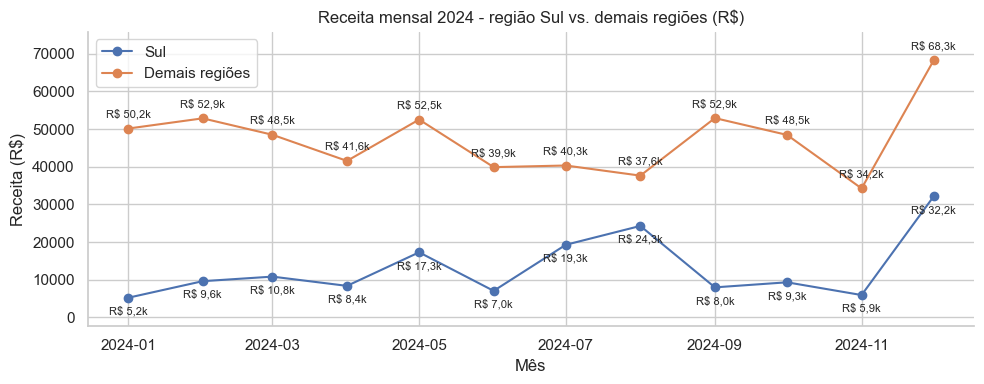

In [8]:
# Q4 - Comparativo região Sul (RS, SC, PR) vs. resto do pais.
# Reusa `con` (DuckDB in-memory) e a view `vendas` registradas no bloco 4 (Q3).

# ---------------------------------------------------------------
# KPI 1 - Volume, receita e ticket médio por grupo (região Sul vs. Demais regiões).
# ---------------------------------------------------------------
sql_kpi1_agregado = """
WITH base AS (
    SELECT
        pedido_id,
        receita,
        CASE WHEN uf IN ('RS', 'SC', 'PR') THEN 'Sul' ELSE 'Demais regiões' END AS grupo
    FROM vendas
    WHERE uf IS NOT NULL
)
SELECT
    grupo,
    COUNT(DISTINCT pedido_id) AS pedidos,
    ROUND(SUM(receita), 2) AS receita_total,
    ROUND(
        SUM(receita) / NULLIF(COUNT(DISTINCT pedido_id), 0),
        2
    ) AS ticket_medio
FROM base
GROUP BY grupo
ORDER BY grupo DESC;
"""
kpis_regiao = con.sql(sql_kpi1_agregado).df()

# KPI 1.b - Desdobramento por UF individual dentro da região Sul.
sql_kpi1_por_uf = """
SELECT
    uf,
    COUNT(DISTINCT pedido_id) AS pedidos,
    ROUND(SUM(receita), 2) AS receita_total,
    ROUND(
        SUM(receita) / NULLIF(COUNT(DISTINCT pedido_id), 0),
        2
    ) AS ticket_medio
FROM vendas
WHERE uf IN ('RS', 'SC', 'PR')
GROUP BY uf
ORDER BY receita_total DESC;
"""
kpis_por_uf_sul = con.sql(sql_kpi1_por_uf).df()

# ---------------------------------------------------------------
# KPI 2 - Taxa de cancelamento + devolução por grupo (mesmo filtro de Q3.b).
# ---------------------------------------------------------------
sql_kpi2 = """
WITH base AS (
    SELECT
        pedido_id,
        status,
        CASE WHEN uf IN ('RS', 'SC', 'PR') THEN 'Sul' ELSE 'Demais regiões' END AS grupo
    FROM vendas
    WHERE uf IS NOT NULL
)
SELECT
    grupo,
    COUNT(*) AS total_pedidos,
    SUM(CASE WHEN status IN ('cancelado', 'devolvido') THEN 1 ELSE 0 END) AS nao_concluidos,
    ROUND(
        100.0 * SUM(CASE WHEN status IN ('cancelado', 'devolvido') THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS taxa_cancel_devol_pct
FROM base
GROUP BY grupo
ORDER BY taxa_cancel_devol_pct DESC;
"""
taxas_cancelamento_regiao = con.sql(sql_kpi2).df()

# ---------------------------------------------------------------
# KPI 3 - Avaliação média por grupo (excluindo nulos).
# ---------------------------------------------------------------
sql_kpi3 = """
WITH base AS (
    SELECT
        avaliacao,
        CASE WHEN uf IN ('RS', 'SC', 'PR') THEN 'Sul' ELSE 'Demais regiões' END AS grupo
    FROM vendas
    WHERE uf IS NOT NULL
      AND avaliacao IS NOT NULL
)
SELECT
    grupo,
    COUNT(*) AS base_avaliada,
    ROUND(AVG(avaliacao), 2) AS avaliacao_media
FROM base
GROUP BY grupo
ORDER BY grupo DESC;
"""
avaliacao_media_regiao = con.sql(sql_kpi3).df()

# ---------------------------------------------------------------
# KPI 4 - Mix de categoria na região Sul vs. demais regiões (receita e participação %).
# ---------------------------------------------------------------
sql_kpi4 = """
WITH base AS (
    SELECT
        categoria,
        receita,
        CASE WHEN uf IN ('RS', 'SC', 'PR') THEN 'Sul' ELSE 'Demais regiões' END AS grupo
    FROM vendas
    WHERE uf IS NOT NULL
),
por_categoria AS (
    SELECT
        categoria,
        grupo,
        ROUND(SUM(receita), 2) AS receita_categoria
    FROM base
    GROUP BY categoria, grupo
),
total_por_grupo AS (
    SELECT grupo, SUM(receita_categoria) AS receita_grupo
    FROM por_categoria
    GROUP BY grupo
)
SELECT
    pc.categoria,
    pc.grupo,
    pc.receita_categoria,
    ROUND(100.0 * pc.receita_categoria / NULLIF(tg.receita_grupo, 0), 2) AS participacao_pct
FROM por_categoria pc
JOIN total_por_grupo tg
    ON tg.grupo = pc.grupo
ORDER BY pc.categoria, pc.grupo DESC;
"""
mix_categoria_sul_vs_resto = con.sql(sql_kpi4).df()

# ---------------------------------------------------------------
# KPI 5 - Tendência mensal de receita em 2024, região Sul vs. demais regiões.
# Filtra pedidos concluídos (consistente com Q3.a).
# ---------------------------------------------------------------
sql_kpi5 = """
SELECT
    DATE_TRUNC('month', data_pedido) AS mes,
    CASE WHEN uf IN ('RS', 'SC', 'PR') THEN 'Sul' ELSE 'Demais regiões' END AS grupo,
    ROUND(SUM(receita), 2) AS receita
FROM vendas
WHERE uf IS NOT NULL
  AND status NOT IN ('cancelado', 'devolvido')
GROUP BY mes, grupo
ORDER BY mes, grupo;
"""
tendencia_mensal_sul_vs_resto = con.sql(sql_kpi5).df()

# ---------------------------------------------------------------
# Print intermediário para rastreabilidade.
# ---------------------------------------------------------------
linha_sul = kpis_regiao[kpis_regiao["grupo"] == "Sul"].iloc[0]
linha_resto = kpis_regiao[kpis_regiao["grupo"] == "Demais regiões"].iloc[0]
razao_ticket = round(linha_sul["ticket_medio"] / linha_resto["ticket_medio"], 2)
print(
    f"Região Sul: {int(linha_sul['pedidos'])} pedidos | Receita total: R$ {linha_sul['receita_total']:.2f}"
    f" | Ticket médio: R$ {linha_sul['ticket_medio']:.2f}"
)
print(
    f"\nDemais regiões: {int(linha_resto['pedidos'])} pedidos | Receita total: R$ {linha_resto['receita_total']:.2f}"
    f" | Ticket médio: R$ {linha_resto['ticket_medio']:.2f}"
)
print(f"\nRazão Ticket médio entre região Sul/demais regiões: {razao_ticket}x")
print()
print("=" * 50)

# ---------------------------------------------------------------
# Outputs tabulares.
# ---------------------------------------------------------------
print("\nKPI 1 - Volume, receita e ticket médio (região Sul vs. demais regiões)")
display(kpis_regiao)
print("KPI 1.b - Desdobramento por UF da região Sul")
display(kpis_por_uf_sul)
print()
print("=" * 50)
print("KPI 2 - Taxa de cancelamento + devolução")
display(taxas_cancelamento_regiao)
print()
print("=" * 50)
print("KPI 3 - Avaliação média (excluindo nulos)")
display(avaliacao_media_regiao)
print()
print("=" * 50)
print("KPI 4 - Mix de categoria")
display(mix_categoria_sul_vs_resto)
print()
print("=" * 50)
print("KPI 5 - Receita mensal 2024")
display(tendencia_mensal_sul_vs_resto)

# ---------------------------------------------------------------
# Gráfico único - tendência mensal (12 meses x 2 grupos não é legivel em tabela).
# ---------------------------------------------------------------
fig, eixo = plt.subplots(figsize=(10, 4))
pivotado = tendencia_mensal_sul_vs_resto.pivot(
    index="mes", columns="grupo", values="receita"
).fillna(0)
for grupo in ("Sul", "Demais regiões"):
    if grupo in pivotado.columns:
        eixo.plot(pivotado.index, pivotado[grupo], marker="o", label=grupo)
        offset_y = 8 if grupo == "Demais regiões" else -12
        for x, y in zip(pivotado.index, pivotado[grupo]):
            eixo.annotate(
                f"R$ {y/1000:.1f}k".replace(".", ","),
                (x, y),
                textcoords="offset points",
                xytext=(0, offset_y),
                ha="center",
                fontsize=8,
            )
eixo.set_title("Receita mensal 2024 - região Sul vs. demais regiões (R$)")
eixo.set_xlabel("Mês")
eixo.set_ylabel("Receita (R$)")
eixo.legend()
eixo.margins(y=0.12)
sns.despine()
plt.tight_layout()
plt.show()


### Q4.1 Análise e recomendação - Sul vs. demais regiões

**Achado principal**
O Sul agrega desempenho competitivo em relação ao restante do país, com ticket médio, taxa de cancelamento e satisfação dentro da média nacional. O problema e a oportunidade estão dentro do Sul, não entre o Sul e o país. Rio Grande do Sul, Santa Catarina e Paraná têm perfis radicalmente distintos, e uma campanha única para a região corre o risco de sacrificar margem onde ela não precisa ser sacrificada (SC) e de não resolver o problema onde ele existe (RS).

**Evidências-chave**

*Volume e valor por pedido*

Sul: `250` pedidos, receita de `R$ 198.494,70`, ticket médio de `R$ 793,98`.
Demais regiões: `918` pedidos, ticket médio de `R$ 763,62`, razão `1,04×` a favor do Sul.

A dispersão interna é o ponto central:

| Estado | Ticket médio | Ranking nacional (13 estados) |
|--------|-------------|-------------------------------|
| Santa Catarina | `R$ 1.122,54` | 1º |
| Paraná | `R$ 729,15` | 7º |
| Rio Grande do Sul | `R$ 582,92` | 11º |

Diferença entre SC e RS: `1,93×`. A amplitude interna do Sul supera a diferença entre o Sul e o restante do país.

*Taxa de não-conclusão (cancelamentos + devoluções)*

Sul: `17,60%` (`44` de `250` pedidos). Demais regiões: `18,74%` (`172` de `918`). O Sul está `1,14` ponto percentual abaixo da média, desempenho operacional não contraindica a campanha.

*Satisfação de clientes*

Sul: `3,87 / 5` (base: `202` avaliações). Demais regiões: `3,93 / 5` (base: `732`). Diferença de `0,06` ponto, praticamente equivalente.

*Mix de categorias*

Impressoras respondem por `23,61%` da receita do Sul contra `17,30%` nas demais regiões. Câmeras e Armazenamento pesam menos no Sul. As comparações de volume e receita incluem pedidos de todos os status; os totais de receita nessas tabelas não equivalem a receita realizada (KPI 5 usa apenas pedidos concluídos, conforme declarado na seção anterior).

*Sazonalidade (pedidos concluídos)*

Receita mensal do Sul varia de `R$ 5.207` (janeiro) a `R$ 32.151` (dezembro), amplitude de `~6,2×`. Demais regiões oscilam entre `R$ 34.248` e `R$ 68.278`, amplitude de `~2,0×`. Julho a agosto foram atipicamente altos no Sul (`~R$ 20-24k`); junho, setembro e novembro foram vales.

**O que isso significa para o negócio**

O Sul não é um mercado deficiente que precisa de estímulo indiscriminado. Santa Catarina opera com o maior ticket médio do Brasil sem desconto; campanha horizontal reduziria margem desnecessariamente neste estado. O Rio Grande do Sul, com ticket médio `R$ 582,92` e 11º lugar nacional, é o candidato mais claro a intervenção, mas o diagnóstico de causa ainda não está fechado: a diferença pode vir de mix de produto diferente, de menor poder aquisitivo regional ou de outro fator. Sem confirmar a causa, o desconto pode não mover o comportamento esperado.

Uma campanha única pela média compromete os dois lados: sacrifica margem em SC e provavelmente não resolve RS.

**Ressalvas**

- **Amostra restrita por estado:** RS (`99`), SC (`78`) e PR (`73`) pedidos. As médias de ticket são sensíveis a poucos pedidos atípicos.
- **Um ano de histórico (2024):** sem base anterior, não é possível estimar se a campanha produziria incremento real ou apenas redistribuiria receita com desconto. Elasticidade-preço não pode ser calculada.
- **Sem dados de margem ou custo:** nenhuma projeção de retorno sobre desconto é sustentável com os dados disponíveis.
- **Sem abertura por categoria dentro de cada estado:** a diferença de ticket entre RS, PR e SC pode refletir mix de produto, não disposição a pagar; confirmar esse ponto mudaria o desenho da campanha.
- **Sazonalidade não explicada:** picos de julho a agosto no Sul sem causa identificada.
- **Sem experimento controlado prévio:** não é possível atribuir causalidade a nenhuma diferença entre regiões.

**Recomendação: `prosseguir com ressalvas`**

A evidência sustenta avançar no planejamento, mas não sustenta campanha única para o Sul. O próximo passo recomendado é segmentar por estado: SC como mercado de retenção e upsell, PR como mercado intermediário e RS como estado-alvo prioritário para elevar o ticket médio. Antes de definir o mecanismo de desconto, é necessário confirmar se a diferença de valor entre os estados vem de mix de categoria ou de comportamento de compra. Se houver pressão para agir no curto prazo, priorizar ação estado-específica em janela de vale identificada (junho, setembro ou novembro para RS), nunca desconto amplo Sul-agregado.

# Bloco 6: Q5 - Debug

## Q5 - Encontre o Erro

O script `scripts/analise_crescimento.py` foi usado para produzir o gráfico
"Receita total por categoria — crescimento YoY" apresentado à diretoria, que
gerou decisões estratégicas sobre quais categorias receberiam maior investimento.

O script afirma calcular o **crescimento Year-over-Year (YoY) da receita por
categoria** — isto é, quanto cada categoria cresceu em relação ao mesmo período
do ano anterior.

Foram identificados **dois erros graves** que invalidam os resultados:

1. **Erro 1 — Dataset bruto sem filtro de status:** o script lê o arquivo bruto
   (`ecommerce_vendas.csv`) sem nenhum filtro de `status`, incluindo pedidos
   `cancelado` e `devolvido` na soma de receita.

2. **Erro 2 — "YoY" não é YoY e a base é indefinida:** a variável `primeiro_mes`
   é calculada mas jamais utilizada (*dead code*), revelando a intenção original
   nunca implementada. A função `crescimento` usa `grupo.iloc[0]["receita"]` como
   base sem ordenar o grupo por data, tornando a base dependente da ordem dos
   dados. Além disso, o dataset contém apenas o ano de 2024 — cálculo YoY
   (mesmo período, ano anterior) é **impossível por definição** sem dados de 2023.

Nesta **Fase 1**, o código abaixo:
- reproduz o gráfico histórico apresentado à diretoria;
- compara esse artefato com a saída literal do script versionado;
- mostra a leitura corrigida com base determinística e filtro de status válido.

A análise narrativa consolidada está na próxima célula.

In [ ]:
# =============================================================
# Q5 — Debug: scripts/analise_crescimento.py
# =============================================================
# Fase 1 da auditoria:
#   1. reproduz o gráfico histórico apresentado à diretoria;
#   2. contrasta esse artefato com a saída literal do script versionado;
#   3. apresenta o gráfico corrigido com base determinística e filtro de status.
# A [MD análise] fica reservada para a Fase 2.
# =============================================================

# Fixa a ordem e os valores do artefato apresentado à diretoria, pontos de referência imutáveis da auditoria.
ORDEM_CATEGORIAS = [
    "Monitores",
    "Armazenamento",
    "Acessórios",
    "Periféricos",
    "Câmeras",
    "Impressoras",
]

ARTEFATO_HISTORICO_PCT = {
    "Monitores": 129.5,
    "Armazenamento": 46.8,
    "Acessórios": -7.1,
    "Periféricos": -32.7,
    "Câmeras": -48.8,
    "Impressoras": -52.9,
}


def formatar_brl(valor):
    """Padroniza a exibição monetária da auditoria em reais com separadores PT-BR."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def formatar_pct(valor):
    """Padroniza a exibição percentual usada nos rótulos dos gráficos de Q5."""
    return f"{valor:.1f}%"


def reordenar_por_categoria(df, coluna_valor):
    """Alinha o recorte à `ORDEM_CATEGORIAS` para comparar artefato histórico, script e versão corrigida lado a lado."""
    return (
        df[["categoria", coluna_valor]]
        .drop_duplicates(subset=["categoria"])
        .set_index("categoria")
        .reindex(ORDEM_CATEGORIAS)
        .reset_index()
    )


def calcular_variacao_mensal_ordenada(df_cat_mes, coluna_saida):
    """Ancora o crescimento em jan/2024 ordenando cada categoria por mês antes do `iloc[0]`, neutralizando o Erro 2."""
    partes = []
    for _, grupo in df_cat_mes.groupby("categoria"):
        grupo = grupo.sort_values("mes").copy()
        base = grupo.iloc[0]["receita"]
        grupo[coluna_saida] = (grupo["receita"] / base - 1) * 100
        partes.append(grupo)

    resultado = pd.concat(partes, ignore_index=True)
    ultimo_mes = resultado[resultado["mes"] == resultado["mes"].max()].copy()
    return resultado, reordenar_por_categoria(ultimo_mes, coluna_saida)


def reproduzir_script_literal(df_bruto):
    """Executa o pipeline do `analise_crescimento.py` sem correções, expondo o efeito do `iloc[0]` sobre a base não ordenada."""
    receita_mes = df_bruto.groupby(["categoria", "mes"])["receita"].sum().reset_index()
    partes = []
    for _, grupo in receita_mes.groupby("categoria"):
        grupo = grupo.copy()
        base = grupo.iloc[0]["receita"]
        grupo["script_literal_pct"] = (grupo["receita"] / base - 1) * 100
        partes.append(grupo)

    resultado = pd.concat(partes, ignore_index=True)
    ultimo_mes = resultado[resultado["mes"] == resultado["mes"].max()].copy()
    return reordenar_por_categoria(ultimo_mes, "script_literal_pct")


def plotar_grafico_q5(
    ax,
    dados_plot,
    coluna_percentual,
    identificacao,
    subtitulo,
    eixo_y,
    legenda,
    rodape,
    categorias_destacadas,
    y_limites,
):
    """Renderiza o gráfico padronizado de Q5 com escala Y compartilhada entre artefato histórico e versão corrigida."""
    azul = "#2f67d8"
    cinza = "#6e7f99"
    cores = [
        azul if categoria in categorias_destacadas else cinza
        for categoria in dados_plot["categoria"]
    ]

    barras = ax.bar(
        dados_plot["categoria"],
        dados_plot[coluna_percentual],
        color=cores,
        edgecolor="white",
        linewidth=0.8,
        width=0.62,
        zorder=3,
    )

    ax.set_title(
        f"{identificacao}\nCrescimento de receita por categoria — 2024\n{subtitulo}",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )
    ax.set_ylabel(eixo_y)
    ax.set_ylim(*y_limites)
    ax.axhline(0, color="#495057", linewidth=0.8, zorder=2)
    ax.grid(axis="y", color="#d9dee7", linewidth=0.9, alpha=0.9, zorder=1)
    ax.set_facecolor("#fbfcfe")
    ax.tick_params(axis="x", rotation=23, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#d9dee7")
    ax.spines["bottom"].set_color("#d9dee7")

    rotulos = [formatar_pct(valor) for valor in dados_plot[coluna_percentual]]
    ax.bar_label(barras, labels=rotulos, padding=3, fontsize=9, fontweight="bold")
    ax.legend(
        handles=[Patch(facecolor=azul, edgecolor="white", label=legenda)],
        loc="upper right",
        frameon=False,
        fontsize=8,
    )
    ax.text(
        0.0,
        -0.19,
        rodape,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        color="#7a7f87",
    )


def formatar_mes_ano(periodo):
    """Converte Period('YYYY-MM') para rótulo abreviado (ex.: Jan/2024)."""
    meses_pt = {
        1: "Jan",
        2: "Fev",
        3: "Mar",
        4: "Abr",
        5: "Mai",
        6: "Jun",
        7: "Jul",
        8: "Ago",
        9: "Set",
        10: "Out",
        11: "Nov",
        12: "Dez",
    }
    return f"{meses_pt[periodo.month]}/{periodo.year}"


def plotar_grafico_corrigido_mom(ax, mom_pivot):
    """Renderiza o gráfico corrigido em linha com variação MoM por categoria."""
    paleta = plt.get_cmap("tab10")
    meses_rotulos = [formatar_mes_ano(periodo) for periodo in mom_pivot.index]
    eixo_x_base = list(range(len(meses_rotulos)))
    quantidade_categorias = len(mom_pivot.columns)
    if quantidade_categorias <= 1:
        offsets = [0.0]
    else:
        abertura_total = 0.60
        passo_offset = abertura_total / (quantidade_categorias - 1)
        offsets = [(-abertura_total / 2) + (i * passo_offset) for i in range(quantidade_categorias)]

    for indice, categoria in enumerate(mom_pivot.columns):
        deslocamento_x = offsets[indice]
        eixo_x_categoria = [x + deslocamento_x for x in eixo_x_base]
        serie_categoria = mom_pivot[categoria].values
        ax.plot(
            eixo_x_categoria,
            serie_categoria,
            label=categoria,
            color=paleta(indice),
            linewidth=2.1,
            marker="o",
            markersize=4.6,
            zorder=3,
        )

        deslocamento_rotulo_y = ((indice % 3) - 1) * 8
        deslocamento_rotulo_x = ((indice % 2) * 4) - 2
        for x_valor, y_valor in zip(eixo_x_categoria, serie_categoria):
            if not (y_valor == y_valor):
                continue
            ax.annotate(
                formatar_pct(y_valor),
                xy=(x_valor, y_valor),
                xytext=(deslocamento_rotulo_x, 10 + deslocamento_rotulo_y),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7,
                color=paleta(indice),
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "fc": "white",
                    "ec": "none",
                    "alpha": 0.78,
                },
            )

    valores_validos = mom_pivot.stack().dropna()
    limite_inferior = min(0, valores_validos.min())
    limite_superior = max(0, valores_validos.max())
    amplitude = limite_superior - limite_inferior
    margem = max(12, amplitude * 0.12)

    ax.set_title(
        "Q5 — Gráfico corrigido\n"
        "Variação de receita mensal por categoria — 2024\n"
        "(MoM, com filtro de status válido)",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )
    ax.set_ylabel("Variação da receita mensal MoM (%)")
    ax.set_xlabel("Mês")
    ax.set_xticks(eixo_x_base)
    ax.set_xticklabels(meses_rotulos, rotation=23, ha="right")
    ax.set_xlim(min(eixo_x_base) - 0.6, max(eixo_x_base) + 0.6)
    ax.set_ylim(limite_inferior - margem, limite_superior + margem)
    ax.axhline(0, color="#495057", linewidth=0.8, zorder=2)
    ax.grid(axis="y", color="#d9dee7", linewidth=0.9, alpha=0.9, zorder=1)
    ax.set_facecolor("#fbfcfe")
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#d9dee7")
    ax.spines["bottom"].set_color("#d9dee7")
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
        fontsize=8,
        title="Categoria",
        title_fontsize=9,
    )
    ax.text(
        0.0,
        -0.17,
        "Fonte: data/interim/ecommerce_tratado.csv | "
        "MoM calculado sobre receita mensal filtrada por status válido",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        color="#7a7f87",
    )


# ---------------------------------------------------------------
# Carga das bases
# ---------------------------------------------------------------
df_bruto_original = pd.read_csv(RAW_PATH)
df_bruto_original["data_pedido"] = pd.to_datetime(
    df_bruto_original["data_pedido"], dayfirst=True, errors="coerce"
)
df_bruto_original["mes"] = df_bruto_original["data_pedido"].dt.to_period("M")
df_bruto_original["receita"] = (
    df_bruto_original["qtd"]
    * df_bruto_original["valor_unit"]
    * (1 - df_bruto_original["desconto_%"].fillna(0) / 100)
)

# Base tratada espelha o insumo real do script legado; df_valido aplica o filtro de status que o Erro 1 ignorou.
df_tratado = pd.read_csv(INTERIM_DIR / "ecommerce_tratado.csv")
df_tratado["data_pedido"] = pd.to_datetime(df_tratado["data_pedido"])
df_tratado["mes"] = df_tratado["data_pedido"].dt.to_period("M")

status_validos = ["entregue", "em_transito"]
status_invalidos = ["cancelado", "devolvido"]
df_valido = df_tratado[df_tratado["status"].isin(status_validos)].copy()


# ---------------------------------------------------------------
# Evidência objetiva dos dois erros já identificados
# ---------------------------------------------------------------
print("=== EVIDÊNCIA — ERRO 1: receita inflada por status inválido ===")
print(df_tratado["status"].value_counts().to_string())

receita_invalida = df_tratado[df_tratado["status"].isin(status_invalidos)]["receita"].sum()
receita_valida = df_valido["receita"].sum()
inflacao_total_pct = receita_invalida / receita_valida * 100

print(f"\nReceita inválida (cancelado + devolvido): {formatar_brl(receita_invalida)}")
print(f"Receita válida (entregue + em_transito): {formatar_brl(receita_valida)}")
print(f"Inflação total causada pelo Erro 1: {inflacao_total_pct:.1f}%")

print("\n=== EVIDÊNCIA — ERRO 2: 'YoY' impossível + base dependente da ordem ===")
anos_disponiveis = sorted(int(ano) for ano in df_tratado["data_pedido"].dt.year.unique())
print(f"Anos presentes no dataset: {anos_disponiveis}")
print("YoY real exigiria o mesmo período de 2023, que não existe nesta base.")

receita_mes_tratado = (
    df_tratado.groupby(["categoria", "mes"])["receita"].sum().reset_index()
)
# Embaralha a base para expor a dependência de ordem do iloc[0]; random_state fixo mantém a evidência reproduzível.
receita_mes_desordenado = receita_mes_tratado.sample(frac=1, random_state=7).reset_index(drop=True)

print("\nSensibilidade do `iloc[0]` quando a ordem dos dados muda:")
print(
    f"{'Categoria':<16} {'Base jan/2024':>18} "
    f"{'Base iloc[0]':>18} {'Mês escolhido':>15}"
)
for categoria in sorted(receita_mes_tratado["categoria"].unique()):
    base_ordenada = (
        receita_mes_tratado[receita_mes_tratado["categoria"] == categoria]
        .sort_values("mes")
        .iloc[0]["receita"]
    )
    grupo_desordenado = receita_mes_desordenado[receita_mes_desordenado["categoria"] == categoria]
    base_iloc = grupo_desordenado.iloc[0]["receita"]
    mes_iloc = grupo_desordenado.iloc[0]["mes"]
    alerta = " <- DIFERENTE" if base_ordenada != base_iloc else ""
    print(
        f"{categoria:<16} {formatar_brl(base_ordenada):>18} "
        f"{formatar_brl(base_iloc):>18} {str(mes_iloc):>15}{alerta}"
    )


# ---------------------------------------------------------------
# Série histórica: artefato apresentado, script literal e leitura corrigida
# ---------------------------------------------------------------
historico_df = pd.DataFrame(
    {
        "categoria": ORDEM_CATEGORIAS,
        "artefato_historico_pct": [ARTEFATO_HISTORICO_PCT[c] for c in ORDEM_CATEGORIAS],
    }
)

script_literal_df = reproduzir_script_literal(df_bruto_original)

receita_mes_corrigida = (
    df_valido.groupby(["categoria", "mes"])["receita"].sum().reset_index()
)
resultado_corrigido, corrigido_df = calcular_variacao_mensal_ordenada(
    receita_mes_corrigida,
    coluna_saida="corrigido_pct",
)
mom_corrigido = receita_mes_corrigida.sort_values(["categoria", "mes"]).copy()
mom_corrigido["mom_pct"] = mom_corrigido.groupby("categoria")["receita"].pct_change() * 100
mom_corrigido_pivot = (
    mom_corrigido.pivot(index="mes", columns="categoria", values="mom_pct")
    .reindex(columns=ORDEM_CATEGORIAS)
    .sort_index()
)

cobertura_corrigida = (
    receita_mes_corrigida.groupby("categoria")["mes"]
    .agg(primeiro_mes="min", ultimo_mes="max", meses_distintos="nunique")
    .reset_index()
    .set_index("categoria")
    .reindex(ORDEM_CATEGORIAS)
    .reset_index()
)

# Consolida as três leituras na mesma granularidade de categoria para quantificar as divergências em pontos percentuais.
comparativo_q5 = (
    historico_df.merge(script_literal_df, on="categoria", how="left")
    .merge(corrigido_df, on="categoria", how="left")
)
comparativo_q5["dif_hist_vs_script_pp"] = (
    comparativo_q5["artefato_historico_pct"] - comparativo_q5["script_literal_pct"]
).round(1)
comparativo_q5["dif_hist_vs_corrigido_pp"] = (
    comparativo_q5["artefato_historico_pct"] - comparativo_q5["corrigido_pct"]
).round(1)
comparativo_q5["script_vs_corrigido_pp"] = (
    comparativo_q5["script_literal_pct"] - comparativo_q5["corrigido_pct"]
).round(1)

for coluna in [
    "artefato_historico_pct",
    "script_literal_pct",
    "corrigido_pct",
]:
    comparativo_q5[coluna] = comparativo_q5[coluna].round(1)

print("\nCobertura mensal da base corrigida por categoria:")
print(cobertura_corrigida.to_string(index=False))

print("\n=== ACHADO FORMAL ADICIONAL — artefato histórico vs. script versionado ===")
print(
    "O gráfico apresentado à diretoria não é totalmente reproduzível a partir "
    "do `scripts/analise_crescimento.py`. A tabela abaixo mostra essa divergência."
)

print("\nTabela comparativa da auditoria de Q5 (em pontos percentuais):")
print(comparativo_q5.to_string(index=False))


# ---------------------------------------------------------------
# Gráficos padronizados: original histórico vs. corrigido
# ---------------------------------------------------------------
# Mantém a escala do gráfico histórico ancorada no recorte jan→dez para preservar o comparativo com o artefato.
valores_y = pd.concat(
    [
        comparativo_q5["artefato_historico_pct"],
        comparativo_q5["corrigido_pct"],
        comparativo_q5["script_literal_pct"],
    ],
    ignore_index=True,
)
limite_inferior = min(0, valores_y.min())
limite_superior = max(0, valores_y.max())
amplitude = limite_superior - limite_inferior
margem = max(12, amplitude * 0.12)
y_limites = (limite_inferior - margem, limite_superior + margem)

print(
    "\nOs dois gráficos abaixo complementam a auditoria: o primeiro reproduz "
    "o artefato histórico e o segundo mostra a variação mensal MoM da base corrigida."
)

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    plotar_grafico_q5(
        ax=ax,
        dados_plot=historico_df,
        coluna_percentual="artefato_historico_pct",
        identificacao="Q5 — Gráfico original apresentado à diretoria",
        subtitulo="(base: primeiro mês de registro)",
        eixo_y="Crescimento de receita (%)",
        legenda="Categorias recomendadas para expansão",
        rodape="Fonte: Sistema legado TechShop | Análise: jan-dez 2024",
        categorias_destacadas=["Monitores"],
        y_limites=y_limites,
    )
    plt.tight_layout()
    plt.show()

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(11.6, 6.2))
    plotar_grafico_corrigido_mom(ax=ax, mom_pivot=mom_corrigido_pivot)
    plt.tight_layout()
    plt.show()


### Q5, análise consolidada (Fase 2)

#### Achado principal

O gráfico "Receita total por categoria, crescimento YoY" que sustentou decisões de investimento da diretoria foi gerado a partir de um script com duas falhas graves. A primeira incluiu receita de pedidos `cancelados` e `devolvidos` como se fossem venda realizada, inflando a receita em `24,0%`. A segunda calculou a variação de crescimento usando como ponto de partida uma base de comparação dependente da ordem em que os dados chegam, em vez de ancorar em `jan/2024`. O rótulo `YoY` (crescimento ano contra ano) é ainda tecnicamente impossível, já que o dataset contém apenas `2024`.

#### Evidências-chave

Receita indevidamente somada pelo filtro ausente: `R$ 175.599,53` sobre `R$ 731.085,80` de receita válida (pedidos `entregue` e `em_transito`).

Base de comparação instável: em `6 de 6` categorias testadas, o ponto de partida difere de `jan/2024` quando os dados chegam em ordem diferente. Por exemplo, `Impressoras` passa a ancorar em `ago/2024` (`R$ 12.984,90`) em vez de `jan/2024` (`R$ 3.994,85`), distorcendo a leitura de crescimento de forma integral.

Comparativo entre o gráfico histórico e a leitura corrigida (base `jan/2024` a `dez/2024`, dataset tratado, apenas pedidos válidos):

| Categoria | Original | Corrigido | Divergência |
|---|---:|---:|---|
| `Impressoras` | `-52,9%` | `+259,5%` | `-312,4 pp`, inversão de sinal |
| `Câmeras` | `-48,8%` | `+17,8%` | `-66,6 pp`, inversão de sinal |
| `Monitores` | `+129,5%` | `+103,2%` | `+26,3 pp`, magnitude menor |
| `Armazenamento` | `+46,8%` | `+81,7%` | `-34,9 pp`, magnitude maior |
| `Acessórios` | `-7,1%` | `-6,4%` | `-0,7 pp`, praticamente equivalente |
| `Periféricos` | `-32,7%` | `-34,4%` | `+1,7 pp`, praticamente equivalente |

#### Impacto no gráfico original

O gráfico apresentado à diretoria destacou `Monitores` e `Armazenamento` como categorias a expandir e posicionou `Impressoras`, `Câmeras` e `Periféricos` como quedas significativas. A leitura corrigida inverte duas dessas leituras de forma direta. `Impressoras` deixa de ser apresentada como a maior queda e passa a ser a maior alta (`+259,5%`). `Câmeras` sai de queda pronunciada (`-48,8%`) e vira leve alta (`+17,8%`). Duas das seis categorias invertem de sinal e outras duas mudam sensivelmente de magnitude quando os dois erros do script são corrigidos.

#### O que isso significa para o negócio

Nenhuma decisão de alocação de investimento por categoria deve seguir baseada no gráfico original sem revalidação. As leituras mais críticas são `Impressoras` e `Câmeras`: ambas foram apresentadas ao comitê como queda relevante e aparecem com sinal oposto na leitura corrigida, portanto qualquer decisão de investimento para essas categorias precisa ser reavaliada antes da execução. `Monitores` e `Armazenamento` mantêm sinal positivo, mas com magnitudes que diferem entre `26` e `35` pontos percentuais: `Armazenamento` foi subestimado em `34,9 pp` e pode estar sub-investido; `Monitores` foi superestimado em `26,3 pp`. O dimensionamento do investimento para ambas as categorias precisa ser refeito com a magnitude correta. `Acessórios` e `Periféricos` ficam praticamente equivalentes entre as duas leituras.

#### Ressalvas

A base contém apenas `2024`. O rótulo `YoY` é impossível por definição sem dados de `2023`. A métrica corrigida é explicitamente "variação de receita MoM (de `jan/2024` a `dez/2024`)", não `YoY`.

Ancorar a leitura em dois meses extremos é frágil. A evolução mensal MoM é altamente volátil: `Impressoras` oscila de `+199,4%` em `fev/2024` a `-75,4%` em `jun/2024` e volta a `+188,3%` em `ago/2024`. `Câmeras` oscila entre `+254,9%` (`set/2024`) e `-65,7%` (`nov/2024`). Qualquer métrica ancorada em apenas dois meses herda esse ruído.

Inconsistência adicional de auditoria: o gráfico histórico apresentado à diretoria não é totalmente reproduzível hoje a partir do script versionado. A causa não foi identificada nesta auditoria e não deve ser atribuída a nenhum fator sem investigação. Trata-se de um problema de governança analítica, não de um terceiro erro causal do script.

O filtro `status` em (`entregue`, `em_transito`) inclui pedidos ainda em trânsito, que podem ser futuramente cancelados ou devolvidos. Aceitável para leitura retrospectiva de `2024`, revisável se a análise passar a suportar decisão operacional.

#### Correção recomendada

**O que estava errado no script original (`scripts/analise_crescimento.py`):**
1. Leitura do dataset bruto sem filtro de `status`, incluindo pedidos `cancelado` e `devolvido` na soma de receita. Consequência: receita inflada em `24,0%`.
2. Base de comparação calculada pela primeira linha do grupo sem ordenar por mês. Consequência: base varia em `6 de 6` categorias quando os dados chegam desordenados.
3. Rótulo `YoY` sobre base que contém apenas `2024`. Métrica impossível por definição.

**O que foi corrigido na Fase 1 (célula `q5_debug_code`):**
1. Leitura passa a ser do dataset tratado de Q2, com filtro para apenas pedidos `entregue` e `em_transito`.
2. Cálculo ancora a base de comparação em `jan/2024` de forma determinística em todas as categorias.
3. Métrica é renomeada para "crescimento de receita de `jan/2024` a `dez/2024`", explicitamente não `YoY`. O gráfico corrigido usa a mesma escala de Y do artefato histórico para permitir comparação visual direta.

**O que ainda depende de validação adicional:**
1. Investigar a causa da divergência entre o gráfico histórico e a saída literal do script versionado. Hipóteses possíveis (script editado após a geração da figura, base de dados diferente à época, outro pipeline) não têm evidência no output desta auditoria.
2. Definir uma métrica de crescimento mais robusta que não dependa de dois meses âncora, dada a volatilidade mensal observada. Alternativas razoáveis: totais anuais, médias móveis trimestrais ou `CAGR` parcial.
3. Revalidar especificamente as decisões estratégicas já tomadas com base no artefato original, em especial para `Impressoras` e `Câmeras`, cujas leituras corrigidas invertem de sinal.

**Recomendação final:** a análise de crescimento por categoria no formato apresentado à diretoria não é confiável o suficiente para sustentar decisão de alocação de investimento. O artefato precisa ser reconstruído a partir do dataset tratado, com métrica robusta, antes de ser reutilizado em comitê.

# Bloco 7: Q6 - Modelagem Dimensional

## Q6 - Modelagem

_A preencher via `/modelar-dimensional` (markdown-only)._

# Bloco 8: Q7 - Insight

## Q7 - Pergunta Livre

_A preencher via `/insight-livre`._